<a href="https://colab.research.google.com/github/adikatre/Asymmetric-Cross-Modal-Attention/blob/main/notebooks/train_evaluate_visualize_colab_unfrozen_5_gcp_s7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2 — Train, Evaluate & Test

Compare **independent directional weights** with two shared symmetric experts.
Both variants use parallel updates from original encoder features and have exactly
the same parameter count. The symmetric control uses four attention calls versus two;
this is a parameter-matched comparison, not a compute-matched weight-tying ablation.

CLIP ViT-B/32 and RoBERTa remain frozen. Their raw hidden states are cached once,
while the modality projections, fusion blocks, and classifier are trained. This keeps
the A100 focused on the comparison rather than repeating encoder inference each epoch.

The campaign uses paired seeds, a shared 12-epoch recipe, and official VQA validation
scores over every validation question. Historical seed-7 results remain in `artifacts/`;
their filtered validation set and simplified scores are not directly comparable.
Test2015 staging is deferred to the GCP run. Export remains optional until data is present.


In [1]:
EXPECTED_FUSION_PARAMS = 6_306_816
EXPECTED_ACTIVE_TOTAL_PARAMS = 221_259_704
EXPECTED_ACTIVE_TRAINABLE_PARAMS = 221_259_704
EXPECTED_FROZEN_HEAD_PARAMS = 9_158_072


def count_parameters(module, trainable_only=False):
    return sum(
        p.numel() for p in module.parameters()
        if not trainable_only or p.requires_grad
    )


def audit_active_architectures():
    """Fail fast on parameter drift, broken symmetry, or unused experts."""
    asymmetric = AsymmetricCrossModalFusion(EMBED_DIM, NUM_HEADS, dropout=0.0)
    matched = ParameterMatchedSymmetricCrossModalFusion(
        EMBED_DIM, NUM_HEADS, dropout=0.0)

    fusion_counts = {
        "asymmetric": count_parameters(asymmetric),
        "symmetric_matched": count_parameters(matched),
    }
    assert set(fusion_counts.values()) == {EXPECTED_FUSION_PARAMS}, fusion_counts

    # Projection/classifier-inclusive frozen heads must remain exactly matched.
    asym_head = AsymmetricVQAModel(NUM_ANSWERS, EMBED_DIM, NUM_HEADS, dropout=0.0)
    matched_head = ParameterMatchedSymmetricVQAModel(
        NUM_ANSWERS, EMBED_DIM, NUM_HEADS, dropout=0.0)
    head_counts = {
        "asymmetric": count_parameters(asym_head),
        "symmetric_matched": count_parameters(matched_head),
    }
    assert set(head_counts.values()) == {EXPECTED_FROZEN_HEAD_PARAMS}, head_counts

    image = torch.randn(2, 4, EMBED_DIM)
    text = torch.randn(2, 3, EMBED_DIM)
    text_padding_mask = torch.tensor([[False, False, True], [False, False, False]])

    # One finite optimizer step per active fusion; every matched expert must train.
    for name, fusion in [("asymmetric", asymmetric),
                         ("symmetric_matched", matched)]:
        fusion.train()
        optimizer = torch.optim.SGD(fusion.parameters(), lr=1e-4)
        optimizer.zero_grad(set_to_none=True)
        img_out, txt_out, attn_i2t, attn_t2i = fusion(
            image, text, text_padding_mask, return_attention=True)
        assert img_out.shape == image.shape and txt_out.shape == text.shape
        assert attn_i2t.shape == (2, 4, 3) and attn_t2i.shape == (2, 3, 4)
        loss = img_out.square().mean() + txt_out.square().mean()
        assert torch.isfinite(loss), (name, loss)
        loss.backward()
        if name in ("symmetric_matched", "asymmetric"):
            missing = [
                param_name for param_name, param in fusion.named_parameters()
                if param.grad is None or not torch.isfinite(param.grad).all()
            ]
            assert not missing, f"Matched experts missing finite gradients: {missing}"
        optimizer.step()

    # With identical-shaped modalities, swapping inputs must swap matched outputs.
    matched.eval()
    x = torch.randn(2, 3, EMBED_DIM)
    y = torch.randn(2, 3, EMBED_DIM)
    with torch.no_grad():
        xy_img, xy_txt, _, _ = matched(x, y)
        yx_img, yx_txt, _, _ = matched(y, x)
    torch.testing.assert_close(xy_img, yx_txt)
    torch.testing.assert_close(xy_txt, yx_img)

    del asymmetric, matched, asym_head, matched_head
    print("Architecture audit passed:", fusion_counts, head_counts)


# Invoked immediately after all fusion and model classes are defined.


In [2]:
!pip install -q torch torchvision transformers matplotlib tqdm Pillow h5py


/bin/bash: line 1: pip: command not found


In [3]:
# Anchor every path to the repository root so the run behaves identically whether
# the kernel starts in notebooks/, at the repo root, or under papermill/nbconvert
# on a headless GCP VM. Relative paths break under the last case.
import os
from pathlib import Path


def _resolve_project_root():
    if os.environ.get("VQA_PROJECT_ROOT"):
        return Path(os.environ["VQA_PROJECT_ROOT"]).expanduser().resolve()
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data").is_dir():
            return candidate
    if Path("/content").is_dir():
        return Path("/content")
    return cwd


PROJECT_ROOT = _resolve_project_root()
DATA_DIR     = Path(os.environ.get("VQA_DATA_DIR", PROJECT_ROOT / "data"))
OUTPUT_ROOT  = Path(os.environ.get("VQA_OUTPUT_DIR", PROJECT_ROOT))

for _name in ["checkpoints", "metrics", "figures", "predictions"]:
    (OUTPUT_ROOT / _name).mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}  (exists={DATA_DIR.is_dir()})")
print(f"OUTPUT_ROOT  : {OUTPUT_ROOT}")

_missing = [p.name for p in [DATA_DIR / "questions", DATA_DIR / "answers",
                             DATA_DIR / "images"] if not p.is_dir()]
if _missing:
    print(f"WARNING: missing data subdirectories under {DATA_DIR}: {_missing}")

PROJECT_ROOT : /mnt/vqa-data/repo
DATA_DIR     : /mnt/vqa-data/data  (exists=True)
OUTPUT_ROOT  : /mnt/vqa-data/work/runs/frozen-gcp-20260913T163839Z/output


In [4]:
import gc
import hashlib
import json
import math
import os
import random
import re
import string
import time
from collections import Counter
from contextlib import nullcontext
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import transformers
from PIL import Image
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm
from transformers import (
    CLIPVisionModel,
    RobertaModel,
    RobertaTokenizer,
    get_cosine_schedule_with_warmup,
)

# Fast tokenizers fork badly inside DataLoader workers; silence the retry storm.
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | torch {torch.__version__} | "
      f"transformers {transformers.__version__}")

# Throughput flags (Ampere/A100): TF32 matmuls + autotuned cuDNN kernels.
# Use the same numerical settings for both models; record versions in each run.
if device.type == "cuda":
    _gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {_gpu.name} | {_gpu.total_memory / 1024**3:.1f} GB")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
else:
    print("WARNING: no CUDA device visible. The smoke test, the cost benchmark "
          "(which hard-fails off-GPU), and full training all assume an A100.")


Device: cuda | torch 2.14.0+cu130 | transformers 5.17.0
GPU: NVIDIA A100-SXM4-40GB | 39.5 GB


## Configuration

Edit these variables to change the experiment.

In [5]:
# Paths (DATA_DIR and OUTPUT_ROOT were resolved in the workspace-paths cell above)
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
METRICS_DIR    = OUTPUT_ROOT / "metrics"
FIGURES_DIR    = OUTPUT_ROOT / "figures"

# Model
NUM_ANSWERS      = 3000
EMBED_DIM        = 512
NUM_HEADS        = 8
DROPOUT          = 0.1
FREEZE_ENCODERS  = True

# Vision profiles: the lightweight profile is used for training; legacy is benchmark-only.
VISION_PROFILES = {
    "lightweight_base32": {
        "model_name": "openai/clip-vit-base-patch32",
        "image_size": 224, "patch_size": 32, "hidden_size": 768,
        "training_mode": "full",
        "batch_size": 128,
    },
    "legacy_large336": {
        "model_name": "openai/clip-vit-large-patch14-336",
        "image_size": 336, "patch_size": 14, "hidden_size": 1024,
        "training_mode": "last4",
        "batch_size": 32,
    },
}
ACTIVE_VISION_PROFILE = "lightweight_base32"
_vision_cfg = VISION_PROFILES[ACTIVE_VISION_PROFILE]
IMAGE_ENCODER_NAME   = _vision_cfg["model_name"]
IMAGE_SIZE           = _vision_cfg["image_size"]
IMAGE_PATCH_SIZE     = _vision_cfg["patch_size"]
IMAGE_SEQ_LEN        = (IMAGE_SIZE // IMAGE_PATCH_SIZE) ** 2 + 1
IMAGE_HIDDEN_DIM     = _vision_cfg["hidden_size"]
TEXT_HIDDEN_DIM      = 768
VISION_TRAINING_MODE = _vision_cfg["training_mode"]

# Data
MAX_QUESTION_LEN = 20
MAX_SAMPLES      = None    # set to 1000 for a quick dev run, and None for a complete run

# Training
if FREEZE_ENCODERS:
    # Cached 70-token features are lightweight enough for a high-throughput
    # A100 batch without involving either frozen backbone.
    BATCH_SIZE       = 2048
    FEATURE_EXTRACTION_BATCH_SIZE = 512
    LEARNING_RATE    = 2e-4
    ENCODER_LR       = 0.0
    WARMUP_EPOCHS    = 0
    GRAD_ACCUM_STEPS = 1
else:
    BATCH_SIZE       = _vision_cfg["batch_size"]  # A100 40 GB target
    LEARNING_RATE    = 2e-4   # fusion + classifier + projection LR
    ENCODER_LR       = 2e-6   # fully unfrozen CLIP/RoBERTa encoder LR
    WARMUP_EPOCHS    = 1
    GRAD_ACCUM_STEPS = 1

WEIGHT_DECAY        = 1e-2
MAX_GRAD_NORM       = 1.0
MAX_EPOCHS          = 12
EPOCHS              = MAX_EPOCHS  # compatibility alias used by existing plots/schedulers
# Fixed training horizon for both variants; select the best checkpoint afterward.
EVAL_SUBSET_SIZE     = 10_000
NUM_WORKERS         = min(8, os.cpu_count() or 1)
PREFETCH_FACTOR     = 2
SEED                = 7  # smoke tests and initial dataset construction
SEEDS               = (7, 42, 123)
VAL_SUBSET_SEED     = 2026
GPU_BUDGET_HOURS    = 12.0
EXPORT_RESERVE_HOURS = 1.5
BOOTSTRAP_SAMPLES   = 2000
METRIC_VERSION     = "vqa_official_leave_one_out_v1"
EXPERIMENT_VERSION = "directional_parallel_v1"

# A configuration/data fingerprint is appended after dataset construction.
RUN_TAG = f"clipB32_224_frozen_top{NUM_ANSWERS}_{EXPERIMENT_VERSION}"
USE_AMP             = True
SMOKE_TEST_STEPS    = 25
BENCHMARK_VAL_SAMPLES   = 4_096
RUN_PREFLIGHT_BENCHMARK = True
REPORT_TOP1000_COMPAT = True

for d in [CHECKPOINT_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)


---
## 1. Data Loading

In [6]:
# OpenAI CLIP preprocessing constants shared by the active and legacy profiles.
CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

# Follow GT-Vision-Lab/VQA's evaluator, including its punctuation/contraction rules.
# Reference: https://github.com/GT-Vision-Lab/VQA/blob/master/PythonEvaluationTools/vqaEvaluation/vqaEval.py
NUMBER_MAP = dict(zip(
    ("none", "zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten"),
    ("0", "0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10")))
ARTICLES = {"a", "an", "the"}
CONTRACTIONS = {"'ow'sat": "'ow's'at",
 "'ows'at": "'ow's'at",
 "I'dve": "I'd've",
 "Id've": "I'd've",
 'Im': "I'm",
 'Ive': "I've",
 'aint': "ain't",
 'arent': "aren't",
 'cant': "can't",
 "couldn'tve": "couldn't've",
 'couldnt': "couldn't",
 "couldnt've": "couldn't've",
 'couldve': "could've",
 'didnt': "didn't",
 'doesnt': "doesn't",
 'dont': "don't",
 "hadn'tve": "hadn't've",
 'hadnt': "hadn't",
 "hadnt've": "hadn't've",
 'hasnt': "hasn't",
 'havent': "haven't",
 "he'dve": "he'd've",
 'hed': "he'd",
 "hed've": "he'd've",
 'hes': "he's",
 'howd': "how'd",
 'howll': "how'll",
 'hows': "how's",
 'isnt': "isn't",
 "it'dve": "it'd've",
 'itd': "it'd",
 "itd've": "it'd've",
 'itll': "it'll",
 "let's": "let's",
 'maam': "ma'am",
 "mightn'tve": "mightn't've",
 'mightnt': "mightn't",
 "mightnt've": "mightn't've",
 'mightve': "might've",
 'mustnt': "mustn't",
 'mustve': "must've",
 'neednt': "needn't",
 'notve': "not've",
 'oclock': "o'clock",
 'oughtnt': "oughtn't",
 "ow's'at": "'ow's'at",
 'shant': "shan't",
 "she'dve": "she'd've",
 "she's": "she's",
 "shed've": "she'd've",
 "shouldn'tve": "shouldn't've",
 'shouldnt': "shouldn't",
 "shouldnt've": "shouldn't've",
 'shouldve': "should've",
 "somebody'd": 'somebodyd',
 "somebody'dve": "somebody'd've",
 "somebodyd've": "somebody'd've",
 'somebodyll': "somebody'll",
 'somebodys': "somebody's",
 "someone'dve": "someone'd've",
 'someoned': "someone'd",
 "someoned've": "someone'd've",
 'someonell': "someone'll",
 'someones': "someone's",
 "something'dve": "something'd've",
 'somethingd': "something'd",
 "somethingd've": "something'd've",
 'somethingll': "something'll",
 'thats': "that's",
 "there'dve": "there'd've",
 'thered': "there'd",
 "thered've": "there'd've",
 'therere': "there're",
 'theres': "there's",
 "they'dve": "they'd've",
 'theyd': "they'd",
 "theyd've": "they'd've",
 'theyll': "they'll",
 'theyre': "they're",
 'theyve': "they've",
 'twas': "'twas",
 'wasnt': "wasn't",
 "we'dve": "we'd've",
 "wed've": "we'd've",
 'werent': "weren't",
 'weve': "we've",
 'whatll': "what'll",
 'whatre': "what're",
 'whats': "what's",
 'whatve': "what've",
 'whens': "when's",
 'whered': "where'd",
 'wheres': "where's",
 'whereve': "where've",
 "who'dve": "who'd've",
 'whod': "who'd",
 "whod've": "who'd've",
 'wholl': "who'll",
 'whos': "who's",
 'whove': "who've",
 'whyll': "why'll",
 'whyre': "why're",
 'whys': "why's",
 'wont': "won't",
 "wouldn'tve": "wouldn't've",
 'wouldnt': "wouldn't",
 "wouldnt've": "wouldn't've",
 'wouldve': "would've",
 "y'all'dve": "y'all'd've",
 "y'alld've": "y'all'd've",
 "y'allll": "y'all'll",
 'yall': "y'all",
 "yall'd've": "y'all'd've",
 "yall'll": "y'all'll",
 "you'dve": "you'd've",
 'youd': "you'd",
 "youd've": "you'd've",
 'youll': "you'll",
 'youre': "you're",
 'youve': "you've"}
VQA_PUNCT = [';', '/', '[', ']', '"', '{', '}', '(', ')', '=', '+',
             '\\', '_', '-', '>', '<', '@', '`', ',', '?', '!']
VQA_PERIOD = re.compile(r"(?!<=\d)(\.)(?!\d)")
VQA_COMMA = re.compile(r"(\d)(,)(\d)")


def normalize_answer(answer):
    """Official VQA punctuation, number/article, and contraction processing."""
    text = str(answer).replace("\n", " ").replace("\t", " ").strip()
    original = text
    for punctuation in VQA_PUNCT:
        remove = (punctuation + " " in original or " " + punctuation in original
                  or VQA_COMMA.search(original) is not None)
        text = text.replace(punctuation, "" if remove else " ")
    text = VQA_PERIOD.sub("", text)
    words = [NUMBER_MAP.get(word, word) for word in text.lower().split()
             if word not in ARTICLES]
    return " ".join(CONTRACTIONS.get(word, word) for word in words)


def official_answer_counts(answers):
    """The official evaluator normalizes answers only when annotators disagree."""
    cleaned = [str(a["answer"]).replace("\n", " ").replace("\t", " ").strip()
               for a in answers]
    if len(cleaned) != 10:
        raise ValueError("VQA v2 evaluation requires ten annotator answers per question.")
    if len(set(cleaned)) > 1:
        cleaned = [normalize_answer(a) for a in cleaned]
    return Counter(cleaned)


def official_score(count):
    """Average min(matches/3, 1) over the ten leave-one-annotator-out sets."""
    return (count * min(max(count - 1, 0) / 3.0, 1.0)
            + (10 - count) * min(count / 3.0, 1.0)) / 10.0


def build_answer_vocab(annotations_file, top_k=3000):
    """Build answer vocabulary from the top_k most frequent normalized answers."""
    with open(annotations_file) as f:
        annotations = json.load(f)["annotations"]

    counter = Counter()
    for ann in annotations:
        ans = normalize_answer(ann["multiple_choice_answer"])
        if ans:
            counter[ans] += 1

    most_common = [ans for ans, _ in counter.most_common(top_k)]
    answer_to_idx = {ans: idx for idx, ans in enumerate(most_common)}
    idx_to_answer = {idx: ans for ans, idx in answer_to_idx.items()}
    return answer_to_idx, idx_to_answer


def get_image_transform(split="train"):
    """CLIP-normalized transform at the active vision profile's resolution."""
    interpolation = transforms.InterpolationMode.BICUBIC
    if split == "train":
        return transforms.Compose([
            transforms.RandomResizedCrop(
                IMAGE_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1),
                interpolation=interpolation),
            transforms.ToTensor(),
            transforms.Normalize(mean=CLIP_MEAN, std=CLIP_STD),
        ])
    return transforms.Compose([
        transforms.Resize(IMAGE_SIZE, interpolation=interpolation),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=CLIP_MEAN, std=CLIP_STD),
    ])


def get_h5_preprocess_transform():
    """Resize/crop raw JPEGs to IMAGE_SIZE for versioned HDF5 storage."""
    interpolation = transforms.InterpolationMode.BICUBIC
    return transforms.Compose([
        transforms.Resize(IMAGE_SIZE, interpolation=interpolation),
        transforms.CenterCrop(IMAGE_SIZE),
    ])


## Storage as one .h5 file

Images are stored in a versioned HDF5 file at `IMAGE_SIZE x IMAGE_SIZE` so incompatible resolution caches are never reused.


In [7]:
# --- HDF5 Preprocessing: convert raw JPEGs into a single contiguous file ---
# The cache is ~18 GB at 224px and takes tens of minutes to build, so a spot-VM
# preemption mid-write is likely. A "complete" flag plus a "num_written" cursor
# make the build resumable and stop a half-written file (whose trailing rows are
# all zeros) from being silently reused as if it were a finished cache.
h5_path = DATA_DIR / f"vqa_images_{IMAGE_SIZE}.h5"

image_dirs = [DATA_DIR / "images" / "train2014", DATA_DIR / "images" / "val2014"]
all_paths = []
if h5_path.exists():
    with h5py.File(h5_path, "r") as h5f:
        stored_shape = tuple(h5f["images"].shape[1:3])
        stored_count = h5f["images"].shape[0]
        num_written = int(h5f.attrs.get("num_written", 0))
        if "complete" in h5f.attrs:
            cache_complete = bool(h5f.attrs["complete"])
        else:
            # Legacy caches predate resumable-build attributes. Accept one only
            # when both datasets are populated and aligned; zero is not a COCO ID.
            image_ids = h5f["image_ids"][:]
            cache_complete = (stored_count > 0 and len(image_ids) == stored_count
                              and bool(np.all(image_ids != 0)))
            if cache_complete:
                num_written = stored_count
    if stored_shape != (IMAGE_SIZE, IMAGE_SIZE):
        raise ValueError(
            f"{h5_path} holds images of {stored_shape}, expected "
            f"{(IMAGE_SIZE, IMAGE_SIZE)}. "
            "Delete/regenerate it instead of reusing an incompatible cache.")
else:
    num_written, cache_complete = 0, False

if not cache_complete:
    missing_dirs = [str(d) for d in image_dirs if not d.is_dir()]
    if missing_dirs:
        raise FileNotFoundError(
            f"Missing image directories: {missing_dirs}. Extract train2014 and "
            "val2014 before building an absent or incomplete image cache.")
    for d in image_dirs:
        all_paths.extend(sorted(d.glob("*.jpg")))
    if not all_paths:
        raise FileNotFoundError(f"No JPEGs found under {[str(d) for d in image_dirs]}")
    print(f"Found {len(all_paths):,} images for the {IMAGE_SIZE}px cache")
    if h5_path.exists() and stored_count != len(all_paths):
        raise ValueError(
            f"{h5_path} holds {stored_count:,} images, expected {len(all_paths):,}. "
            "Delete/regenerate it instead of resuming an incompatible cache.")

if not h5_path.exists():
    with h5py.File(h5_path, "w") as h5f:
        h5f.create_dataset(
            "images", shape=(len(all_paths), IMAGE_SIZE, IMAGE_SIZE, 3),
            dtype=np.uint8, chunks=(1, IMAGE_SIZE, IMAGE_SIZE, 3))
        h5f.create_dataset("image_ids", shape=(len(all_paths),), dtype=np.int64)
        h5f.attrs["num_written"] = 0
        h5f.attrs["complete"] = False

if cache_complete:
    print(f"HDF5 cache already complete at {IMAGE_SIZE}px: {h5_path} "
          f"({stored_count:,} images; raw JPEGs not required)")
else:
    preprocess = get_h5_preprocess_transform()
    if num_written:
        print(f"Resuming interrupted HDF5 build at image {num_written:,}")
    with h5py.File(h5_path, "a") as h5f:
        imgs_ds, ids_ds = h5f["images"], h5f["image_ids"]
        for i in tqdm(range(num_written, len(all_paths)), desc="Preprocessing images"):
            path = all_paths[i]
            imgs_ds[i] = np.array(preprocess(Image.open(path).convert("RGB")))
            ids_ds[i] = int(path.stem.split("_")[-1])
            if (i + 1) % 2000 == 0:
                h5f.attrs["num_written"] = i + 1
                h5f.flush()
        h5f.attrs["num_written"] = len(all_paths)
        h5f.attrs["complete"] = True

    print(f"Saved {len(all_paths):,} images to {h5_path}")


HDF5 cache already complete at 224px: /mnt/vqa-data/data/vqa_images_224.h5 (123,287 images; raw JPEGs not required)


In [8]:
class VQADataset(Dataset):
    """PyTorch dataset for VQA v2.0 with HDF5 image loading and VQA-score targets.

    Returns (image_tensor, input_ids, attention_mask, answer_target) tuples.
    Training uses min(count / 3, 1) soft BCE targets. Validation uses official
    leave-one-out scores and keeps out-of-vocabulary questions (zero vectors).
    The four-tensor batch interface is unchanged.
    """

    def __init__(self, questions_file, annotations_file, h5_path,
                 answer_to_idx=None, top_k_answers=3000,
                 max_question_len=20, transform=None, max_samples=None, training=False):
        self.h5_path = Path(h5_path)
        self.max_question_len = max_question_len
        self.training = training
        self.seed = SEED
        self.epoch = 0
        self.transform = transform or get_image_transform("val")
        self.tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
        self._h5f = None  # lazy-opened per DataLoader worker

        if answer_to_idx is None:
            self.answer_to_idx, self.idx_to_answer = build_answer_vocab(
                annotations_file, top_k_answers)
        else:
            self.answer_to_idx = answer_to_idx
            self.idx_to_answer = {v: k for k, v in answer_to_idx.items()}

        # Build image_id -> HDF5 row index mapping
        with h5py.File(self.h5_path, "r") as f:
            image_ids = f["image_ids"][:]
        self.id_to_row = {int(iid): i for i, iid in enumerate(image_ids)}

        with open(questions_file) as f:
            questions_data = json.load(f)["questions"]
        with open(annotations_file) as f:
            annotations_data = json.load(f)["annotations"]

        ann_by_qid = {ann["question_id"]: ann for ann in annotations_data}
        num_answers = len(self.answer_to_idx)

        self.samples = []
        for q in questions_data:
            ann = ann_by_qid.get(q["question_id"])
            if ann is None:
                raise ValueError(f"Missing annotation for question {q['question_id']}")

            target = torch.zeros(num_answers, dtype=torch.float)
            answer_counts = (Counter(normalize_answer(a["answer"]) for a in ann["answers"])
                             if training else official_answer_counts(ann["answers"]))
            for ans_text, count in answer_counts.items():
                if ans_text in self.answer_to_idx:
                    target[self.answer_to_idx[ans_text]] = (
                        min(count / 3.0, 1.0) if training else official_score(count))

            # Training-only filtering: evaluation must retain every question.
            if training and target.sum() == 0:
                continue

            self.samples.append({
                "question": q["question"],
                "question_id": int(q["question_id"]),
                "multiple_choice_answer": ann["multiple_choice_answer"],
                "answer_type": ann["answer_type"],
                "image_id": q["image_id"],
                "answer_target": target,
            })
            if max_samples is not None and len(self.samples) >= max_samples:
                break

    def set_epoch(self, seed, epoch):
        self.seed, self.epoch = int(seed), int(epoch)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Lazy HDF5 open (per-worker for multiprocessing safety)
        if self._h5f is None:
            self._h5f = h5py.File(self.h5_path, "r")

        row = self.id_to_row[sample["image_id"]]
        img_array = self._h5f["images"][row]  # (IMAGE_SIZE, IMAGE_SIZE, 3) uint8
        image = Image.fromarray(img_array)
        if self.training:
            # Independent of attention/dropout RNG and worker scheduling.
            aug_seed = int.from_bytes(hashlib.sha256(
                f"{self.seed}:{self.epoch}:{sample['question_id']}".encode()).digest()[:8], "little")
            with torch.random.fork_rng(devices=[]):
                torch.random.default_generator.manual_seed(aug_seed)
                image = self.transform(image)
        else:
            image = self.transform(image)

        encoding = self.tokenizer(
            sample["question"],
            max_length=self.max_question_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        return image, input_ids, attention_mask, sample["answer_target"]


In [9]:
# Build answer vocab from training annotations
train_ann = DATA_DIR / "answers" / "v2_mscoco_train2014_annotations.json"
answer_to_idx, idx_to_answer = build_answer_vocab(train_ann, NUM_ANSWERS)
print(f"Answer vocab: {len(answer_to_idx)} normalized classes")

# Create datasets (loading images from versioned HDF5)
train_ds = VQADataset(
    questions_file=DATA_DIR / "questions" / "v2_OpenEnded_mscoco_train2014_questions.json",
    annotations_file=train_ann,
    h5_path=h5_path,
    answer_to_idx=answer_to_idx,
    max_question_len=MAX_QUESTION_LEN,
    transform=get_image_transform("train"),
    training=True,
    max_samples=MAX_SAMPLES,
)
val_ds = VQADataset(
    questions_file=DATA_DIR / "questions" / "v2_OpenEnded_mscoco_val2014_questions.json",
    annotations_file=DATA_DIR / "answers" / "v2_mscoco_val2014_annotations.json",
    h5_path=h5_path,
    answer_to_idx=answer_to_idx,
    max_question_len=MAX_QUESTION_LEN,
    transform=get_image_transform("val"),
    max_samples=MAX_SAMPLES,
)

# Compute priors once from training targets, never validation/test labels.
answer_priors = torch.zeros(NUM_ANSWERS, dtype=torch.float64)
for sample in train_ds.samples:
    answer_priors += sample["answer_target"]
answer_priors = (answer_priors / len(train_ds)).float().clamp(1e-6, 1 - 1e-6)


def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


DATA_FINGERPRINT = {
    p.name: file_sha256(p) for p in [
        train_ann, DATA_DIR / "answers" / "v2_mscoco_val2014_annotations.json",
        DATA_DIR / "questions" / "v2_OpenEnded_mscoco_train2014_questions.json",
        DATA_DIR / "questions" / "v2_OpenEnded_mscoco_val2014_questions.json"]}
VOCAB_SHA256 = hashlib.sha256(json.dumps(answer_to_idx, sort_keys=True).encode()).hexdigest()
FEATURE_CACHE_CONFIG = {
    "format": "raw_hidden_fp16_v1", "preprocess": "clip_center_crop_v1",
    "image_encoder": IMAGE_ENCODER_NAME, "image_size": IMAGE_SIZE,
    "image_hidden_dim": IMAGE_HIDDEN_DIM, "text_encoder": "roberta-base",
    "text_hidden_dim": TEXT_HIDDEN_DIM, "question_length": MAX_QUESTION_LEN,
    "num_answers": NUM_ANSWERS, "max_samples": MAX_SAMPLES,
    "vocab_sha256": VOCAB_SHA256, "data_fingerprint": DATA_FINGERPRINT,
}
FEATURE_CACHE_SHA256 = hashlib.sha256(
    json.dumps(FEATURE_CACHE_CONFIG, sort_keys=True).encode()).hexdigest()
EXPERIMENT_CONFIG = {
    "experiment_version": EXPERIMENT_VERSION, "metric_version": METRIC_VERSION,
    "fusion_flow": "parallel", "embed_dim": EMBED_DIM, "heads": NUM_HEADS,
    "dropout": DROPOUT, "freeze_encoders": FREEZE_ENCODERS,
    "image_encoder": IMAGE_ENCODER_NAME, "image_size": IMAGE_SIZE,
    "vision_training_mode": "frozen" if FREEZE_ENCODERS else VISION_TRAINING_MODE,
    "cached_feature_dtype": "float16" if FREEZE_ENCODERS else None,
    "image_hidden_dim": IMAGE_HIDDEN_DIM, "text_hidden_dim": TEXT_HIDDEN_DIM,
    "text_encoder": "roberta-base", "question_length": MAX_QUESTION_LEN,
    "num_answers": NUM_ANSWERS, "batch_size": BATCH_SIZE,
    "head_lr": LEARNING_RATE, "encoder_lr": ENCODER_LR,
    "weight_decay": WEIGHT_DECAY, "grad_clip": MAX_GRAD_NORM,
    "grad_accum_steps": GRAD_ACCUM_STEPS, "epochs": EPOCHS,
    "warmup_epochs": WARMUP_EPOCHS, "use_amp": USE_AMP,
    "answer_prior_init": True, "train_target": "min_count_over_3",
    "max_samples": MAX_SAMPLES, "val_subset_seed": VAL_SUBSET_SEED,
    "val_subset_size": EVAL_SUBSET_SIZE, "vocab_sha256": VOCAB_SHA256,
    "data_fingerprint": DATA_FINGERPRINT,
    "feature_cache_sha256": FEATURE_CACHE_SHA256,
}
CONFIG_SHA256 = hashlib.sha256(json.dumps(EXPERIMENT_CONFIG, sort_keys=True).encode()).hexdigest()
_encoder_mode_tag = "frozen" if FREEZE_ENCODERS else "fullft"
RUN_TAG = f"clipB32_224_{_encoder_mode_tag}_top{NUM_ANSWERS}_{EXPERIMENT_VERSION}_{CONFIG_SHA256[:12]}"
with open(METRICS_DIR / f"{RUN_TAG}_config.json", "w") as f:
    json.dump(EXPERIMENT_CONFIG, f, indent=2)

_loader_kwargs = {"num_workers": NUM_WORKERS, "pin_memory": device.type == "cuda"}
if NUM_WORKERS:
    _loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **_loader_kwargs)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)

print(f"Train: {len(train_ds):,} samples ({len(train_loader)} batches)")
print(f"Val:   {len(val_ds):,} samples ({len(val_loader)} batches)")

# Save both the latest vocab path and a versioned copy for this run.
with open(CHECKPOINT_DIR / "answer_vocab.json", "w") as f:
    json.dump(answer_to_idx, f, indent=2)
with open(CHECKPOINT_DIR / f"{RUN_TAG}_answer_vocab.json", "w") as f:
    json.dump(answer_to_idx, f, indent=2)


Answer vocab: 3000 normalized classes


Train: 435,073 samples (213 batches)
Val:   214,354 samples (105 batches)


---
## 2. Model Definitions

### Encoders

The lightweight run uses frozen pretrained backbones and trainable modality projections:

- **ImageEncoder** — frozen CLIP ViT-B/32@224, producing 50 raw 768-wide tokens (49 spatial + 1 CLS).
- **TextEncoder** — frozen RoBERTa-base, producing raw 768-wide per-token states.
- **Projection layers** — map both cached streams to `EMBED_DIM` and remain trainable.


In [10]:
class ImageEncoder(nn.Module):
    """Configurable CLIP vision encoder; active output is (B, 50, embed_dim)."""

    def __init__(self, embed_dim=512, freeze=True,
                 model_name=IMAGE_ENCODER_NAME,
                 training_mode=VISION_TRAINING_MODE):
        super().__init__()
        self.clip = CLIPVisionModel.from_pretrained(model_name)
        self.hidden_dim = self.clip.config.hidden_size
        self.patch_size = self.clip.config.patch_size
        self.image_size = self.clip.config.image_size
        self.projection = nn.Linear(self.hidden_dim, embed_dim)

        if freeze:
            for param in self.clip.parameters():
                param.requires_grad = False
        elif training_mode == "full":
            for param in self.clip.parameters():
                param.requires_grad = True
        elif training_mode == "last4":
            # Benchmark-only reproduction of the legacy partial-tuning policy.
            for param in self.clip.parameters():
                param.requires_grad = False
            vision = getattr(self.clip, "vision_model", self.clip)
            for layer in vision.encoder.layers[-4:]:
                for param in layer.parameters():
                    param.requires_grad = True
            if hasattr(vision, "post_layernorm"):
                for param in vision.post_layernorm.parameters():
                    param.requires_grad = True
        else:
            raise ValueError(f"Unknown vision training_mode: {training_mode!r}")

        expected_tokens = (self.image_size // self.patch_size) ** 2 + 1
        if model_name == IMAGE_ENCODER_NAME:
            assert self.image_size == IMAGE_SIZE, (self.image_size, IMAGE_SIZE)
            assert self.patch_size == IMAGE_PATCH_SIZE, (self.patch_size, IMAGE_PATCH_SIZE)
            assert expected_tokens == IMAGE_SEQ_LEN, (expected_tokens, IMAGE_SEQ_LEN)

    def forward(self, images):
        outputs = self.clip(pixel_values=images)
        return self.projection(outputs.last_hidden_state)


class TextEncoder(nn.Module):
    """RoBERTa-base text encoder. Output: (B, seq_len, embed_dim)."""

    ROBERTA_HIDDEN_DIM = 768

    def __init__(self, embed_dim=512, freeze=True):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        self.projection = nn.Linear(self.ROBERTA_HIDDEN_DIM, embed_dim)

        if freeze:
            for param in self.roberta.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        return self.projection(outputs.last_hidden_state)  # (B, seq_len, embed_dim)


### Cross-Attention Blocks

- **Asymmetric:** two independent blocks, one per direction. Both read original encoder features.
- **Symmetric (parameter-matched):** two shared experts, each used in both directions and averaged.
- **Legacy symmetric:** one shared block retained for historical inspection only.

Both active variants have 6,306,816 fusion parameters. Symmetric uses four block calls;
asymmetric uses two. Attention maps are requested explicitly for visualization.


In [11]:
class CrossAttentionBlock(nn.Module):
    """Cross-attention: queries from one modality attend to keys/values from another.
    Includes LayerNorm, residual connections, and a feed-forward network."""

    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        # Pre-norm design: LayerNorm is applied BEFORE attention (not after).
        # This improves training stability for deep networks compared to post-norm.
        self.norm_q = nn.LayerNorm(embed_dim)
        self.norm_kv = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_ff = nn.LayerNorm(embed_dim)
        # Standard Transformer FFN: expand 4x with GELU activation, then project back
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_value, key_padding_mask=None, return_attention=False):
        # Pre-norm cross-attention: normalize inputs, attend, then ADD back the
        # original query (residual). This preserves the raw query signal while
        # enriching it with cross-modal context from key_value.
        q = self.norm_q(query)
        kv = self.norm_kv(key_value)
        attended, attn_weights = self.cross_attn(
            q, kv, kv, key_padding_mask=key_padding_mask,
            need_weights=return_attention, average_attn_weights=True)
        query = query + attended  # residual connection
        # Pre-norm feed-forward + residual (same pattern)
        query = query + self.ff(self.norm_ff(query))
        return query, attn_weights


class AsymmetricCrossModalFusion(nn.Module):
    """Independent directional weights, parallel updates from original features."""

    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.cross_attn_img_to_txt = CrossAttentionBlock(embed_dim, num_heads, dropout)
        self.cross_attn_txt_to_img = CrossAttentionBlock(embed_dim, num_heads, dropout)

    def forward(self, image_features, text_features, text_padding_mask=None, return_attention=False):
        # Step 1: image queries attend to text keys/values
        img_attended, attn_i2t = self.cross_attn_img_to_txt(
            query=image_features, key_value=text_features,
            key_padding_mask=text_padding_mask, return_attention=return_attention)
        # Text also attends to original features: update order is controlled.
        txt_attended, attn_t2i = self.cross_attn_txt_to_img(
            query=text_features, key_value=image_features, return_attention=return_attention)
        return img_attended, txt_attended, attn_i2t, attn_t2i


class LegacySymmetricCrossModalFusion(nn.Module):
    """ONE SHARED cross-attention block used in both directions (baseline).
    Both directions share the same weights and operate on RAW encoder outputs
    independently — no sequential information flow between them."""

    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.shared_cross_attn = CrossAttentionBlock(embed_dim, num_heads, dropout)

    def forward(self, image_features, text_features, text_padding_mask=None, return_attention=False):
        # Apply the same weights in both directions.
        img_attended, attn_i2t = self.shared_cross_attn(
            query=image_features, key_value=text_features,
            key_padding_mask=text_padding_mask, return_attention=return_attention)
        txt_attended, attn_t2i = self.shared_cross_attn(
            query=text_features, key_value=image_features, return_attention=return_attention)
        return img_attended, txt_attended, attn_i2t, attn_t2i


class ParameterMatchedSymmetricCrossModalFusion(nn.Module):
    """Parameter-matched symmetric control with two shared experts.

    Both experts are applied identically in both directions to raw encoder
    features. Averaging the expert outputs preserves directional symmetry
    while matching the asymmetric fusion's two-block parameter budget.
    This matches parameters, not compute: it makes four cross-attention calls.
    """

    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.shared_experts = nn.ModuleList([
            CrossAttentionBlock(embed_dim, num_heads, dropout),
            CrossAttentionBlock(embed_dim, num_heads, dropout),
        ])

    def _apply_experts(self, query, key_value, key_padding_mask=None, return_attention=False):
        outputs, weights = zip(*(
            expert(query=query, key_value=key_value,
                   key_padding_mask=key_padding_mask, return_attention=return_attention)
            for expert in self.shared_experts
        ))
        return (torch.stack(outputs, dim=0).mean(dim=0),
                torch.stack(weights, dim=0).mean(dim=0) if return_attention else None)

    def forward(self, image_features, text_features, text_padding_mask=None, return_attention=False):
        img_attended, attn_i2t = self._apply_experts(
            query=image_features, key_value=text_features,
            key_padding_mask=text_padding_mask, return_attention=return_attention)
        txt_attended, attn_t2i = self._apply_experts(
            query=text_features, key_value=image_features, return_attention=return_attention)
        return img_attended, txt_attended, attn_i2t, attn_t2i

### Full VQA Models

Pipeline: encode image + text → cross-modal fusion → mean-pool → concatenate → MLP classifier

The two models are identical except for the fusion layer.

In [12]:
def pool_image_tokens(image_features):
    """Mean-pool spatial image tokens, excluding CLIP/ViT CLS."""
    return image_features[:, 1:, :].mean(dim=1)


def pool_text_tokens(text_features, attention_mask):
    """Masked mean-pool non-padding RoBERTa tokens."""
    mask = attention_mask.unsqueeze(-1).type_as(text_features)
    denom = mask.sum(dim=1).clamp(min=1.0)
    return (text_features * mask).sum(dim=1) / denom


class AsymmetricVQAModel(nn.Module):
    """Asymmetric VQA head over cached, unprojected encoder hidden states."""

    def __init__(self, num_answers, embed_dim=512, num_heads=8, dropout=0.3):
        super().__init__()
        self.image_projection = nn.Linear(IMAGE_HIDDEN_DIM, embed_dim)
        self.text_projection = nn.Linear(TEXT_HIDDEN_DIM, embed_dim)
        self.fusion = AsymmetricCrossModalFusion(embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(embed_dim, num_answers))

    def forward(self, image_features, text_features, attention_mask, return_attention=False):
        image_features = self.image_projection(image_features)
        text_features = self.text_projection(text_features)
        text_pad_mask = attention_mask == 0
        img_att, txt_att, attn_i2t, attn_t2i = self.fusion(
            image_features, text_features, text_pad_mask, return_attention=return_attention)
        z = torch.cat([
            pool_image_tokens(img_att),
            pool_text_tokens(txt_att, attention_mask),
        ], dim=-1)
        logits = self.classifier(z)
        return logits, {"img_to_txt": attn_i2t, "txt_to_img": attn_t2i}


class LegacySymmetricVQAModel(nn.Module):
    """Legacy symmetric VQA head over cached encoder hidden states."""

    def __init__(self, num_answers, embed_dim=512, num_heads=8, dropout=0.3):
        super().__init__()
        self.image_projection = nn.Linear(IMAGE_HIDDEN_DIM, embed_dim)
        self.text_projection = nn.Linear(TEXT_HIDDEN_DIM, embed_dim)
        self.fusion = LegacySymmetricCrossModalFusion(embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(embed_dim, num_answers))

    def forward(self, image_features, text_features, attention_mask, return_attention=False):
        image_features = self.image_projection(image_features)
        text_features = self.text_projection(text_features)
        text_pad_mask = attention_mask == 0
        img_att, txt_att, attn_i2t, attn_t2i = self.fusion(
            image_features, text_features, text_pad_mask, return_attention=return_attention)
        z = torch.cat([
            pool_image_tokens(img_att),
            pool_text_tokens(txt_att, attention_mask),
        ], dim=-1)
        logits = self.classifier(z)
        return logits, {"img_to_txt": attn_i2t, "txt_to_img": attn_t2i}


class ParameterMatchedSymmetricVQAModel(nn.Module):
    """Parameter-matched symmetric head over cached encoder hidden states."""

    def __init__(self, num_answers, embed_dim=512, num_heads=8, dropout=0.3):
        super().__init__()
        self.image_projection = nn.Linear(IMAGE_HIDDEN_DIM, embed_dim)
        self.text_projection = nn.Linear(TEXT_HIDDEN_DIM, embed_dim)
        self.fusion = ParameterMatchedSymmetricCrossModalFusion(
            embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(embed_dim, num_answers))

    def forward(self, image_features, text_features, attention_mask, return_attention=False):
        image_features = self.image_projection(image_features)
        text_features = self.text_projection(text_features)
        text_pad_mask = attention_mask == 0
        img_att, txt_att, attn_i2t, attn_t2i = self.fusion(
            image_features, text_features, text_pad_mask, return_attention=return_attention)
        z = torch.cat([
            pool_image_tokens(img_att),
            pool_text_tokens(txt_att, attention_mask),
        ], dim=-1)
        logits = self.classifier(z)
        return logits, {"img_to_txt": attn_i2t, "txt_to_img": attn_t2i}


# --- End-to-end models (used when FREEZE_ENCODERS=False) ---

class AsymmetricVQAModelE2E(nn.Module):
    """End-to-end VQA model: encoders + asymmetric fusion + classifier."""

    def __init__(self, num_answers, embed_dim=512, num_heads=8, dropout=0.3,
                 freeze_encoders=False, image_model_name=IMAGE_ENCODER_NAME,
                 vision_training_mode=VISION_TRAINING_MODE):
        super().__init__()
        self.image_encoder = ImageEncoder(
            embed_dim, freeze=freeze_encoders, model_name=image_model_name,
            training_mode=vision_training_mode)
        self.text_encoder = TextEncoder(embed_dim, freeze=freeze_encoders)
        self.fusion = AsymmetricCrossModalFusion(embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(embed_dim, num_answers))

    def forward(self, images, input_ids, attention_mask, return_attention=False):
        img = self.image_encoder(images)
        txt = self.text_encoder(input_ids, attention_mask)
        text_pad_mask = attention_mask == 0
        img_att, txt_att, attn_i2t, attn_t2i = self.fusion(img, txt, text_pad_mask, return_attention=return_attention)
        z = torch.cat([
            pool_image_tokens(img_att),
            pool_text_tokens(txt_att, attention_mask),
        ], dim=-1)
        logits = self.classifier(z)
        return logits, {"img_to_txt": attn_i2t, "txt_to_img": attn_t2i}


class LegacySymmetricVQAModelE2E(nn.Module):
    """Legacy end-to-end model with the lower-capacity symmetric fusion."""

    def __init__(self, num_answers, embed_dim=512, num_heads=8, dropout=0.3,
                 freeze_encoders=False, image_model_name=IMAGE_ENCODER_NAME,
                 vision_training_mode=VISION_TRAINING_MODE):
        super().__init__()
        self.image_encoder = ImageEncoder(
            embed_dim, freeze=freeze_encoders, model_name=image_model_name,
            training_mode=vision_training_mode)
        self.text_encoder = TextEncoder(embed_dim, freeze=freeze_encoders)
        self.fusion = LegacySymmetricCrossModalFusion(embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(embed_dim, num_answers))

    def forward(self, images, input_ids, attention_mask, return_attention=False):
        img = self.image_encoder(images)
        txt = self.text_encoder(input_ids, attention_mask)
        text_pad_mask = attention_mask == 0
        img_att, txt_att, attn_i2t, attn_t2i = self.fusion(img, txt, text_pad_mask, return_attention=return_attention)
        z = torch.cat([
            pool_image_tokens(img_att),
            pool_text_tokens(txt_att, attention_mask),
        ], dim=-1)
        logits = self.classifier(z)
        return logits, {"img_to_txt": attn_i2t, "txt_to_img": attn_t2i}


class ParameterMatchedSymmetricVQAModelE2E(nn.Module):
    """End-to-end VQA model with parameter-matched symmetric fusion."""

    def __init__(self, num_answers, embed_dim=512, num_heads=8, dropout=0.3,
                 freeze_encoders=False, image_model_name=IMAGE_ENCODER_NAME,
                 vision_training_mode=VISION_TRAINING_MODE):
        super().__init__()
        self.image_encoder = ImageEncoder(
            embed_dim, freeze=freeze_encoders, model_name=image_model_name,
            training_mode=vision_training_mode)
        self.text_encoder = TextEncoder(embed_dim, freeze=freeze_encoders)
        self.fusion = ParameterMatchedSymmetricCrossModalFusion(
            embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(embed_dim, num_answers))

    def forward(self, images, input_ids, attention_mask, return_attention=False):
        img = self.image_encoder(images)
        txt = self.text_encoder(input_ids, attention_mask)
        text_pad_mask = attention_mask == 0
        img_att, txt_att, attn_i2t, attn_t2i = self.fusion(img, txt, text_pad_mask, return_attention=return_attention)
        z = torch.cat([
            pool_image_tokens(img_att),
            pool_text_tokens(txt_att, attention_mask),
        ], dim=-1)
        logits = self.classifier(z)
        return logits, {"img_to_txt": attn_i2t, "txt_to_img": attn_t2i}


In [13]:
audit_active_architectures()


Architecture audit passed: {'asymmetric': 6306816, 'symmetric_matched': 6306816} {'asymmetric': 9158072, 'symmetric_matched': 9158072}


### Offline Feature Extraction

CLIP ViT-B/32 and RoBERTa run once in inference mode. Their unprojected FP16 hidden
states are cached in a resumable HDF5 file; training then updates only the two
projection layers, fusion blocks, and classifier.


In [14]:
FEATURES_H5 = DATA_DIR / f"vqa_frozen_features_{FEATURE_CACHE_SHA256[:12]}.h5"

if FREEZE_ENCODERS:
    @torch.inference_mode()
    def extract_and_save_features(image_encoder, text_encoder, dataset, split_name, h5_path,
                                   batch_size=FEATURE_EXTRACTION_BATCH_SIZE,
                                   num_workers=NUM_WORKERS):
        """Resume-safe extraction of raw frozen-backbone hidden states."""
        image_encoder.eval()
        text_encoder.eval()

        # Deterministic preprocessing is required because each item is encoded once.
        orig_transform = dataset.transform
        dataset.transform = get_image_transform("val")
        n = len(dataset)
        use_amp = USE_AMP and device.type == "cuda"

        # Estimate disk usage
        bytes_per_sample = (IMAGE_SEQ_LEN * IMAGE_HIDDEN_DIM
                            + MAX_QUESTION_LEN * TEXT_HIDDEN_DIM) * 2  # float16
        bytes_per_sample += MAX_QUESTION_LEN * 1 + NUM_ANSWERS * 4                         # int8 + float32
        est_gb = n * bytes_per_sample / 1e9


        with h5py.File(h5_path, "a") as h5f:
            group = h5f.require_group(split_name)
            specs = {
                "image_features": ((n, IMAGE_SEQ_LEN, IMAGE_HIDDEN_DIM), "float16"),
                "text_features": ((n, MAX_QUESTION_LEN, TEXT_HIDDEN_DIM), "float16"),
                "attention_mask": ((n, MAX_QUESTION_LEN), "int8"),
                "answer_target": ((n, NUM_ANSWERS), "float32"),
            }
            for name, (shape, dtype) in specs.items():
                if name not in group:
                    group.create_dataset(name, shape=shape, dtype=dtype)
                elif group[name].shape != shape or str(group[name].dtype) != dtype:
                    raise ValueError(f"Incompatible feature cache dataset: {split_name}/{name}")

            idx = int(group.attrs.get("num_written", 0))
            if bool(group.attrs.get("complete", False)) and idx == n:
                print(f"  {split_name}: reusing {n:,} cached samples ({est_gb:.1f} GB)")
                dataset.transform = orig_transform
                return
            if not 0 <= idx <= n:
                raise ValueError(f"Invalid {split_name} feature-cache cursor: {idx}")

            remaining = torch.utils.data.Subset(dataset, range(idx, n))
            loader_kwargs = {"num_workers": num_workers, "pin_memory": device.type == "cuda"}
            if num_workers:
                loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR
            loader = DataLoader(remaining, batch_size=batch_size, shuffle=False, **loader_kwargs)
            print(f"  Extracting {split_name}: {n - idx:,}/{n:,} remaining, {est_gb:.1f} GB total")

            try:
                for batch_i, (images, input_ids, attention_mask, answers) in enumerate(
                        tqdm(loader, desc=f"  {split_name}"), start=1):
                    images = images.to(device, non_blocking=True)
                    input_ids = input_ids.to(device, non_blocking=True)
                    attn_mask_dev = attention_mask.to(device, non_blocking=True)

                    amp_ctx = autocast() if use_amp else nullcontext()
                    with amp_ctx:
                        img_feats = image_encoder.clip(pixel_values=images).last_hidden_state
                        txt_feats = text_encoder.roberta(
                            input_ids=input_ids, attention_mask=attn_mask_dev).last_hidden_state

                    bs = images.size(0)
                    group["image_features"][idx:idx+bs] = img_feats.cpu().half().numpy()
                    group["text_features"][idx:idx+bs] = txt_feats.cpu().half().numpy()
                    group["attention_mask"][idx:idx+bs] = attention_mask.numpy().astype("int8")
                    group["answer_target"][idx:idx+bs] = answers.numpy()
                    idx += bs
                    if batch_i % 20 == 0:
                        group.attrs["num_written"] = idx
                        h5f.flush()
                group.attrs["num_written"] = n
                group.attrs["complete"] = True
                h5f.flush()
            finally:
                dataset.transform = orig_transform
        print(f"  {split_name}: {n:,} samples saved.")

    # --- Run extraction ---
    set_seed(SEED)
    _img_enc = ImageEncoder(EMBED_DIM, freeze=True).to(device)
    _txt_enc = TextEncoder(EMBED_DIM, freeze=True).to(device)
    assert _img_enc.hidden_dim == IMAGE_HIDDEN_DIM
    assert _txt_enc.roberta.config.hidden_size == TEXT_HIDDEN_DIM

    with h5py.File(FEATURES_H5, "a") as _feature_h5:
        stored_config = _feature_h5.attrs.get("feature_cache_sha256")
        if stored_config is not None and stored_config != FEATURE_CACHE_SHA256:
            raise ValueError(f"Feature cache belongs to another encoder/data configuration: {FEATURES_H5}")
        _feature_h5.attrs["feature_cache_sha256"] = FEATURE_CACHE_SHA256

    extract_and_save_features(_img_enc, _txt_enc, train_ds, "train", FEATURES_H5)
    extract_and_save_features(_img_enc, _txt_enc, val_ds,   "val",   FEATURES_H5)

    del _img_enc, _txt_enc
    torch.cuda.empty_cache()

    # Verify before any training starts.
    with h5py.File(FEATURES_H5, "r") as f:
        for split in ["train", "val"]:
            if not bool(f[split].attrs.get("complete", False)):
                raise RuntimeError(f"Incomplete feature cache split: {split}")
            print(f"  {split}: image_features={f[f'{split}/image_features'].shape}, "
                  f"text_features={f[f'{split}/text_features'].shape}")
else:
    print("FREEZE_ENCODERS=False: skipping offline feature extraction.")
    print(f"Training will use raw {IMAGE_SIZE}px images/tokens with fully unfrozen encoders.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_n

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Extracting train: 435,073/435,073 remaining, 52.0 GB total


...

  val: 100%|█████████▉| 417/419 [02:38<00:00,  3.43it/s]

  val: 100%|█████████▉| 418/419 [02:38<00:00,  3.52it/s]

  val: 100%|██████████| 419/419 [02:38<00:00,  3.06it/s]

  val: 100%|██████████| 419/419 [02:39<00:00,  2.62it/s]

  val: 214,354 samples saved.
  train: image_features=(435073, 50, 768), text_features=(435073, 20, 768)
  val: image_features=(214354, 50, 768), text_features=(214354, 20, 768)


### Precomputed Feature Dataset

Reads raw frozen-encoder hidden states directly from HDF5. This bypasses JPEG loading,
image transforms, tokenization, and backbone inference during every training epoch.

In [15]:
if FREEZE_ENCODERS:
    class PrecomputedVQADataset(Dataset):
        """Dataset that reads pre-extracted encoder features from HDF5."""

        def __init__(self, h5_path, split):
            self.h5_path = str(h5_path)
            self.split = split
            self._h5f = None  # lazy-opened per DataLoader worker

            with h5py.File(self.h5_path, "r") as f:
                self.n = f[f"{split}/image_features"].shape[0]

        def __len__(self):
            return self.n

        def _open(self):
            if self._h5f is None:
                self._h5f = h5py.File(self.h5_path, "r")

        def __getitem__(self, idx):
            self._open()

            # Keep cached states in FP16 through host RAM and PCIe; autocast consumes
            # them directly on the A100. Targets remain FP32 for BCE.
            img_feats = torch.from_numpy(
                self._h5f[f"{self.split}/image_features"][idx])
            txt_feats = torch.from_numpy(
                self._h5f[f"{self.split}/text_features"][idx])
            att_mask = torch.from_numpy(
                self._h5f[f"{self.split}/attention_mask"][idx].astype("int64"))     # (20,)
            answer = torch.from_numpy(
                self._h5f[f"{self.split}/answer_target"][idx])                      # (NUM_ANSWERS,)

            return img_feats, txt_feats, att_mask, answer

        def __getitems__(self, indices):
            """Fetch a whole shuffled batch with four HDF5 reads, not thousands."""
            self._open()
            indices = np.asarray(indices, dtype=np.int64)
            order = np.argsort(indices)
            inverse = np.argsort(order)
            sorted_indices = indices[order]
            prefix = f"{self.split}/"
            img = torch.from_numpy(self._h5f[prefix + "image_features"][sorted_indices][inverse])
            txt = torch.from_numpy(self._h5f[prefix + "text_features"][sorted_indices][inverse])
            mask = torch.from_numpy(
                self._h5f[prefix + "attention_mask"][sorted_indices][inverse].astype("int64"))
            answer = torch.from_numpy(self._h5f[prefix + "answer_target"][sorted_indices][inverse])
            return list(zip(img, txt, mask, answer))

    raw_train_ds, raw_val_ds = train_ds, val_ds
    # Shadow the original datasets and loaders with precomputed versions
    train_ds = PrecomputedVQADataset(FEATURES_H5, "train")
    val_ds   = PrecomputedVQADataset(FEATURES_H5, "val")
    train_ds.samples, val_ds.samples = raw_train_ds.samples, raw_val_ds.samples

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **_loader_kwargs)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)

    print(f"Train: {len(train_ds):,} samples ({len(train_loader)} batches)")
    print(f"Val:   {len(val_ds):,} samples ({len(val_loader)} batches)")

    # Sanity check: verify shapes from one batch
    _img, _txt, _mask, _ans = next(iter(val_loader))
    print(f"Batch shapes: img={_img.shape}, txt={_txt.shape}, mask={_mask.shape}, ans={_ans.shape}")
    del _img, _txt, _mask, _ans
else:
    # Rebuild loaders with the active A100 batch size for end-to-end training.
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **_loader_kwargs)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)

    print(f"End-to-end mode (batch_size={BATCH_SIZE})")
    print(f"Train: {len(train_ds):,} samples ({len(train_loader)} batches)")
    print(f"Val:   {len(val_ds):,} samples ({len(val_loader)} batches)")

# Dedicated loader RNG; recreating an epoch gives the same order for either model.
def make_epoch_train_loader(seed, epoch):
    if hasattr(train_ds, "set_epoch"):
        train_ds.set_epoch(seed, epoch)
    generator = torch.Generator().manual_seed(int(seed) + 1_000_003 * int(epoch))
    return DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      generator=generator, **_loader_kwargs)


# The same unfiltered validation subset is used for all model/seed pairs.
VAL_SUBSET_INDICES_PATH = METRICS_DIR / f"{RUN_TAG}_val_subset_indices.json"
_val_subset_n = min(EVAL_SUBSET_SIZE, len(val_ds))
_val_rng = np.random.default_rng(VAL_SUBSET_SEED)
val_subset_indices = sorted(_val_rng.choice(len(val_ds), size=_val_subset_n, replace=False).tolist())
subset_record = {"indices": val_subset_indices,
                 "question_ids": [val_ds.samples[i]["question_id"] for i in val_subset_indices],
                 "config_sha256": CONFIG_SHA256}
if VAL_SUBSET_INDICES_PATH.exists():
    if json.loads(VAL_SUBSET_INDICES_PATH.read_text()) != subset_record:
        raise ValueError(f"Validation subset fingerprint mismatch: {VAL_SUBSET_INDICES_PATH}")
else:
    VAL_SUBSET_INDICES_PATH.write_text(json.dumps(subset_record))
val_subset_loader = DataLoader(
    torch.utils.data.Subset(val_ds, val_subset_indices),
    batch_size=BATCH_SIZE, shuffle=False,
    **_loader_kwargs,
    generator=torch.Generator().manual_seed(VAL_SUBSET_SEED))
print(f"Per-epoch official validation subset: {_val_subset_n:,} questions")


Train: 435,073 samples (213 batches)
Val:   214,354 samples (105 batches)


Batch shapes: img=torch.Size([2048, 50, 768]), txt=torch.Size([2048, 20, 768]), mask=torch.Size([2048, 20]), ans=torch.Size([2048, 3000])
Per-epoch official validation subset: 10,000 questions


---
## 3. Training

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, use_amp, scheduler=None,
                    image_size=IMAGE_SIZE):
    model.train()
    total_loss = 0.0
    correct = 0
    soft_score_sum = 0.0
    optimizer_steps = 0
    skipped_optimizer_steps = 0
    total = 0

    optimizer.zero_grad(set_to_none=True)
    for step, (inp1, inp2, masks, answers) in enumerate(tqdm(loader, desc="  train", leave=False), start=1):
        inp1    = inp1.to(device, non_blocking=True)
        inp2    = inp2.to(device, non_blocking=True)
        masks   = masks.to(device, non_blocking=True)
        answers = answers.to(device, non_blocking=True)
        if inp1.ndim == 4 and inp1.shape[-1] != image_size:
            inp1 = torch.nn.functional.interpolate(
                inp1, size=(image_size, image_size), mode="bicubic", align_corners=False)

        amp_ctx = autocast() if use_amp else nullcontext()
        with amp_ctx:
            logits, _ = model(inp1, inp2, masks)
            loss = criterion(logits, answers)

        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite loss at training step {step}: {loss.item()}")

        # The final accumulation group can contain fewer than GRAD_ACCUM_STEPS batches.
        group_start = ((step - 1) // GRAD_ACCUM_STEPS) * GRAD_ACCUM_STEPS
        loss_for_backward = loss / min(GRAD_ACCUM_STEPS, len(loader) - group_start)
        if scaler is not None:
            scaler.scale(loss_for_backward).backward()
        else:
            loss_for_backward.backward()

        should_step = (step % GRAD_ACCUM_STEPS == 0) or (step == len(loader))
        if should_step:
            if scaler is not None:
                scaler.unscale_(optimizer)
            if MAX_GRAD_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM, error_if_nonfinite=scaler is None)
            if scaler is not None:
                old_scale = scaler.get_scale()
                scaler.step(optimizer)
                scaler.update()
                update_applied = scaler.get_scale() >= old_scale
            else:
                optimizer.step()
                update_applied = True
            optimizer_steps += int(update_applied)
            skipped_optimizer_steps += int(not update_applied)
            optimizer.zero_grad(set_to_none=True)
            if scheduler is not None and update_applied:
                scheduler.step()

        total_loss += loss.item() * answers.size(0)
        soft_score_sum += answers.gather(1, logits.argmax(1, keepdim=True)).sum().item()
        correct += (logits.argmax(dim=1) == answers.argmax(dim=1)).sum().item()
        total += answers.size(0)

    return {"train_loss": total_loss / total, "train_acc": correct / total * 100,
            "train_soft_vqa_acc": soft_score_sum / total * 100,
            "optimizer_steps": optimizer_steps, "skipped_optimizer_steps": skipped_optimizer_steps}


@torch.no_grad()
def evaluate(model, loader, criterion, use_amp, image_size=IMAGE_SIZE, desc="  eval", collect_predictions=False):
    """Validation targets are official scores; optional arrays retain question alignment."""
    prediction_ids, prediction_scores = [], []
    if collect_predictions and not isinstance(loader.sampler, torch.utils.data.SequentialSampler):
        raise ValueError("Prediction collection requires a sequential evaluation loader.")
    model.eval()
    total_loss = 0.0
    vqa_acc_sum = 0.0
    vqa_acc_top1000_sum = 0.0
    total = 0

    for inp1, inp2, masks, answers in tqdm(loader, desc=desc, leave=False):
        inp1    = inp1.to(device, non_blocking=True)
        inp2    = inp2.to(device, non_blocking=True)
        masks   = masks.to(device, non_blocking=True)
        answers = answers.to(device, non_blocking=True)
        if inp1.ndim == 4 and inp1.shape[-1] != image_size:
            inp1 = torch.nn.functional.interpolate(
                inp1, size=(image_size, image_size), mode="bicubic", align_corners=False)

        amp_ctx = autocast() if use_amp else nullcontext()
        with amp_ctx:
            logits, _ = model(inp1, inp2, masks)
            loss = criterion(logits, answers)

        total_loss += loss.item() * answers.size(0)

        preds = logits.argmax(dim=1)
        vqa_scores = answers[torch.arange(answers.size(0), device=answers.device), preds]
        if not torch.isfinite(logits).all():
            raise FloatingPointError("Non-finite validation logits")
        vqa_acc_sum += vqa_scores.sum().item()
        if collect_predictions:
            prediction_ids.extend(preds.cpu().tolist())
            prediction_scores.extend(vqa_scores.cpu().tolist())

        if REPORT_TOP1000_COMPAT:
            n_top = min(1000, logits.size(1))
            preds_top1000 = logits[:, :n_top].argmax(dim=1)
            top1000_scores = answers[torch.arange(answers.size(0), device=answers.device), preds_top1000]
            vqa_acc_top1000_sum += top1000_scores.sum().item()

        total += answers.size(0)

    metrics = {
        "val_loss": total_loss / total,
        "val_vqa_acc": vqa_acc_sum / total * 100,
    }
    if REPORT_TOP1000_COMPAT:
        metrics["val_vqa_acc_top1000"] = vqa_acc_top1000_sum / total * 100
    if collect_predictions:
        dataset = loader.dataset
        indices = list(range(len(dataset)))
        while isinstance(dataset, torch.utils.data.Subset):
            indices = [int(dataset.indices[i]) for i in indices]
            dataset = dataset.dataset
        samples = [dataset.samples[i] for i in indices]
        assert len(samples) == total
        return metrics, {
            "question_id": np.asarray([s["question_id"] for s in samples], dtype=np.int64),
            "image_id": np.asarray([s["image_id"] for s in samples], dtype=np.int64),
            "answer_index": np.asarray(prediction_ids, dtype=np.int32),
            "score": np.asarray(prediction_scores, dtype=np.float64),
        }
    return metrics


In [17]:
ACTIVE_MODEL_TYPES = ("symmetric_matched", "asymmetric")


def make_model(model_type, vision_profile_name=ACTIVE_VISION_PROFILE):
    if model_type not in ACTIVE_MODEL_TYPES:
        raise ValueError(f"Active model_type must be one of {ACTIVE_MODEL_TYPES}, got {model_type!r}")
    profile = VISION_PROFILES[vision_profile_name]
    if FREEZE_ENCODERS:
        if model_type == "asymmetric":
            return AsymmetricVQAModel(NUM_ANSWERS, EMBED_DIM, NUM_HEADS, DROPOUT)
        return ParameterMatchedSymmetricVQAModel(
            NUM_ANSWERS, EMBED_DIM, NUM_HEADS, DROPOUT)

    if model_type == "asymmetric":
        return AsymmetricVQAModelE2E(NUM_ANSWERS, EMBED_DIM, NUM_HEADS, DROPOUT,
                                    freeze_encoders=False,
                                    image_model_name=profile["model_name"],
                                    vision_training_mode=profile["training_mode"])
    return ParameterMatchedSymmetricVQAModelE2E(
        NUM_ANSWERS, EMBED_DIM, NUM_HEADS, DROPOUT, freeze_encoders=False,
        image_model_name=profile["model_name"],
        vision_training_mode=profile["training_mode"])


def build_optimizer_and_scheduler(model, total_training_steps=None):
    """Optimize only projections/fusion/classifier when backbones are frozen."""
    if FREEZE_ENCODERS:
        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(
            params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
            fused=device.type == "cuda")
        return optimizer, None, [("trainable", sum(p.numel() for p in params), LEARNING_RATE)]

    encoder_params = []
    head_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith("image_encoder.clip") or name.startswith("text_encoder.roberta"):
            encoder_params.append(param)
        else:
            head_params.append(param)

    optimizer = torch.optim.AdamW([
        {"params": encoder_params, "lr": ENCODER_LR},
        {"params": head_params,    "lr": LEARNING_RATE},
    ], weight_decay=WEIGHT_DECAY)

    steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
    if total_training_steps is None:
        total_training_steps = max(1, steps_per_epoch * EPOCHS)
    warmup_steps = min(max(0, steps_per_epoch * WARMUP_EPOCHS),
                       max(0, total_training_steps // 10))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=max(1, total_training_steps),
    )
    group_counts = [
        ("encoders", sum(p.numel() for p in encoder_params), ENCODER_LR),
        ("projection+fusion+classifier", sum(p.numel() for p in head_params), LEARNING_RATE),
    ]
    return optimizer, scheduler, group_counts


def cuda_sync():
    if device.type == "cuda":
        torch.cuda.synchronize()


def runtime_metadata():
    return {
        "gpu": torch.cuda.get_device_name(0) if device.type == "cuda" else "cpu",
        # str() matters: torch.__version__ is a TorchVersion instance, and
        # pickling it makes the whole checkpoint unreadable under the
        # weights_only=True default that torch.load uses from 2.6 onward.
        "torch_version": str(torch.__version__),
        "transformers_version": str(transformers.__version__),
    }


def make_paired_model(model_type, seed, check_initialization=True):
    """Match common modules and map identical initial block states into both variants."""
    set_seed(seed)
    model = make_model(model_type)
    blocks = (list(model.fusion.shared_experts) if model_type == "symmetric_matched"
              else [model.fusion.cross_attn_img_to_txt, model.fusion.cross_attn_txt_to_img])
    common = {"classifier": model.classifier}
    if FREEZE_ENCODERS:
        common.update(image_projection=model.image_projection,
                      text_projection=model.text_projection)
    else:
        common.update(image_projection=model.image_encoder.projection,
                      text_projection=model.text_encoder.projection)
    with torch.random.fork_rng(devices=[]):
        for offset, module in enumerate(common.values(), start=100):
            torch.random.default_generator.manual_seed(seed + offset)
            for layer in module.modules():
                if isinstance(layer, nn.Linear):
                    layer.reset_parameters()
        for offset, block in enumerate(blocks, start=200):
            torch.random.default_generator.manual_seed(seed + offset)
            initial = CrossAttentionBlock(EMBED_DIM, NUM_HEADS, DROPOUT)
            block.load_state_dict(initial.state_dict())
    with torch.no_grad():
        model.classifier[-1].bias.copy_(torch.logit(answer_priors))

    def state_hash(module):
        digest = hashlib.sha256()
        for name, tensor in module.state_dict().items():
            digest.update(name.encode())
            digest.update(memoryview(tensor.detach().cpu().contiguous().numpy()).cast("B"))
        return digest.hexdigest()

    modules = {"classifier": model.classifier, "block_0": blocks[0], "block_1": blocks[1],
               "image_projection": common["image_projection"],
               "text_projection": common["text_projection"]}
    if not FREEZE_ENCODERS:
        modules.update(image_encoder=model.image_encoder, text_encoder=model.text_encoder)
    model.initialization_hashes = {name: state_hash(module) for name, module in modules.items()}
    if check_initialization:
        path = METRICS_DIR / f"{RUN_TAG}_s{seed}_initialization.json"
        if path.exists():
            assert json.loads(path.read_text()) == model.initialization_hashes, (
                "Paired initialization changed; check model revisions and runtime versions.")
        else:
            path.write_text(json.dumps(model.initialization_hashes, indent=2))
    assert count_parameters(model.fusion) == EXPECTED_FUSION_PARAMS
    if not FREEZE_ENCODERS:
        assert (count_parameters(model), count_parameters(model, True)) == (
            EXPECTED_ACTIVE_TOTAL_PARAMS, EXPECTED_ACTIVE_TRAINABLE_PARAMS)
    return model.to(device)


def save_checkpoint(payload, path):
    """Atomic replacement leaves the last complete checkpoint usable after preemption."""
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".partial")
    torch.save(payload, temporary)
    temporary.replace(path)


def save_json(payload, path):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".partial")
    temporary.write_text(json.dumps(payload, indent=2))
    temporary.replace(path)


def rng_state():
    return {"python": random.getstate(), "numpy": np.random.get_state(),
            "torch": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all() if device.type == "cuda" else None}


def restore_rng(state):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"].cpu())
    if state["cuda"] is not None and device.type == "cuda":
        torch.cuda.set_rng_state_all([s.cpu() for s in state["cuda"]])


def run_name_for(seed, model_type):
    return f"{RUN_TAG}_s{seed}_{model_type}"


def load_run_checkpoint(path, model_type, seed):
    # Only locally produced checkpoints under this experiment's fingerprint.
    checkpoint = torch.load(path, map_location="cpu", weights_only=False)
    config = checkpoint["config"]
    if (config.get("config_sha256"), config.get("model_type"), config.get("seed")) != (
            CONFIG_SHA256, model_type, seed):
        raise ValueError(f"Incompatible checkpoint: {path}")
    if config.get("runtime") != runtime_metadata():
        raise ValueError("Checkpoint runtime differs; use the recorded environment to resume.")
    return checkpoint


def run_training(model_type, run_name=None, resume_from=None, seed=SEED):
    """Fixed-horizon training with matched initialization and epoch-boundary resume."""
    run_name = run_name or run_name_for(seed, model_type)
    model = make_paired_model(model_type, seed)
    criterion = nn.BCEWithLogitsLoss()
    optimizer, scheduler, groups = build_optimizer_and_scheduler(model)
    use_amp = USE_AMP and device.type == "cuda"
    scaler = GradScaler() if use_amp else None
    print(f"\n{run_name}: {count_parameters(model):,} parameters; optimizer groups {groups}")
    history_path = METRICS_DIR / f"{run_name}_history.json"
    latest_path = CHECKPOINT_DIR / f"{run_name}_latest.pt"
    best_path = CHECKPOINT_DIR / f"{run_name}_best.pt"
    config = {**EXPERIMENT_CONFIG, "config_sha256": CONFIG_SHA256,
              "seed": seed, "model_type": model_type, "runtime": runtime_metadata(),
              "fusion_params": count_parameters(model.fusion),
              "total_params": count_parameters(model),
              "trainable_params": count_parameters(model, True),
              "attention_calls": 4 if model_type == "symmetric_matched" else 2,
              "initialization_hashes": model.initialization_hashes}
    history, start_epoch, best_val_acc, best_epoch = [], 1, -1.0, None
    resume_path = Path(resume_from) if resume_from is not None else latest_path
    if resume_path.exists():
        checkpoint = load_run_checkpoint(resume_path, model_type, seed)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if scheduler is not None:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        if scaler is not None:
            scaler.load_state_dict(checkpoint["scaler_state_dict"])
        history = checkpoint["history"]
        # The JSON also includes time spent writing the most recent checkpoint.
        if history_path.exists():
            disk_history = json.loads(history_path.read_text())
            if len(disk_history) == len(history):
                history = disk_history
        start_epoch = checkpoint["epoch"] + 1
        best_val_acc, best_epoch = checkpoint["best_val_acc"], checkpoint["best_epoch"]
        # Recover a best checkpoint if preempted between the two atomic writes.
        if best_epoch == checkpoint["epoch"]:
            save_checkpoint({"model_state_dict": checkpoint["model_state_dict"],
                             "config": config, **history[-1]}, best_path)
        if not best_path.exists():
            raise FileNotFoundError(f"Earlier best checkpoint is missing: {best_path}")
        restore_rng(checkpoint["rng_state"])
        del checkpoint

    for epoch in range(start_epoch, EPOCHS + 1):
        epoch_loader = make_epoch_train_loader(seed, epoch)
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
        cuda_sync()
        epoch_t0 = train_t0 = time.monotonic()
        train_m = train_one_epoch(model, epoch_loader, criterion, optimizer, scaler,
                                  use_amp, scheduler=scheduler)
        cuda_sync()
        train_elapsed = time.monotonic() - train_t0
        val_t0 = time.monotonic()
        val_m = evaluate(model, val_subset_loader, criterion, use_amp, desc="  official-val-subset")
        cuda_sync()
        val_elapsed = time.monotonic() - val_t0
        is_new_best = val_m["val_vqa_acc"] > best_val_acc
        if is_new_best:
            best_val_acc, best_epoch = val_m["val_vqa_acc"], epoch
        row = {"epoch": epoch, **train_m, **val_m, "metric_version": METRIC_VERSION,
               "validation_scope": "fixed_10k_unfiltered_subset",
               "train_elapsed_s": train_elapsed, "val_elapsed_s": val_elapsed,
               "elapsed_s": train_elapsed + val_elapsed, "stopped_early": False,
               "peak_cuda_memory_gb": (torch.cuda.max_memory_allocated() / 1024**3
                                       if device.type == "cuda" else 0.0)}
        history.append(row)
        checkpoint_t0 = time.monotonic()
        payload = {"epoch": epoch, "model_state_dict": model.state_dict(),
                   "optimizer_state_dict": optimizer.state_dict(),
                   "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
                   "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
                   "rng_state": rng_state(), "config": config, "history": history,
                   "best_val_acc": best_val_acc, "best_epoch": best_epoch}
        save_checkpoint(payload, latest_path)
        if is_new_best:
            save_checkpoint({"model_state_dict": model.state_dict(), "config": config, **row}, best_path)
        row["checkpoint_elapsed_s"] = time.monotonic() - checkpoint_t0
        row["elapsed_s"] = time.monotonic() - epoch_t0
        row["cumulative_gpu_hours"] = sum(h["elapsed_s"] for h in history) / 3600
        save_json(history, history_path)
        print(f"  Epoch {epoch}/{EPOCHS}: train soft score {train_m['train_soft_vqa_acc']:.2f}%, "
              f"official subset {val_m['val_vqa_acc']:.2f}%, {row['elapsed_s']:.0f}s")
    del optimizer, scheduler, scaler
    return model, history


def finish_run(model_type, seed):
    """Train/resume one model, then score its best checkpoint on all validation questions."""
    name = run_name_for(seed, model_type)
    summary_path = METRICS_DIR / f"{name}_summary.json"
    best_path = CHECKPOINT_DIR / f"{name}_best.pt"
    predictions_path = METRICS_DIR / f"{name}_val_predictions.npz"
    if summary_path.exists() and best_path.exists() and predictions_path.exists():
        summary = json.loads(summary_path.read_text())
        assert summary["config_sha256"] == CONFIG_SHA256
        return summary
    model, history = run_training(model_type, seed=seed)
    best = load_run_checkpoint(best_path, model_type, seed)
    model.load_state_dict(best["model_state_dict"])
    del best
    cuda_sync()
    eval_t0 = time.monotonic()
    full_metrics, predictions = evaluate(
        model, val_loader, nn.BCEWithLogitsLoss(), USE_AMP and device.type == "cuda",
        desc=f"  full-val-{model_type}-s{seed}", collect_predictions=True)
    np.savez_compressed(predictions_path, **predictions)
    cuda_sync()
    summary = {"seed": seed, "model_type": model_type, "run_name": name,
               "config_sha256": CONFIG_SHA256, "metric_version": METRIC_VERSION,
               "epochs_completed": len(history), "stopped_early": False,
               "best_epoch": max(history, key=lambda h: h["val_vqa_acc"])["epoch"],
               "best_subset_vqa_acc": max(h["val_vqa_acc"] for h in history),
               "full_val_metrics": full_metrics, "full_val_questions": len(val_ds),
               "training_gpu_hours": sum(h["elapsed_s"] for h in history) / 3600,
               "evaluation_gpu_hours": (time.monotonic() - eval_t0) / 3600,
               "checkpoint": str(best_path), "predictions": str(predictions_path),
               "runtime": runtime_metadata()}
    save_json(summary, summary_path)
    del model, predictions
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return summary


def run_campaign():
    """Only launch another paired seed if the measured remaining work fits the budget."""
    completed = []
    spent_hours = preflight_report["elapsed_s"] / 3600
    for seed in SEEDS:
        for variant in ACTIVE_MODEL_TYPES:
            name = run_name_for(seed, variant)
            history_path = METRICS_DIR / f"{name}_history.json"
            summary_path = METRICS_DIR / f"{name}_summary.json"
            if history_path.exists():
                spent_hours += sum(h["elapsed_s"] for h in json.loads(history_path.read_text())) / 3600
            if summary_path.exists():
                spent_hours += json.loads(summary_path.read_text())["evaluation_gpu_hours"]
    campaign_t0 = time.monotonic()
    for seed in SEEDS:
        remaining_seconds = 0.0
        for variant in ACTIVE_MODEL_TYPES:
            name = run_name_for(seed, variant)
            summary_path = METRICS_DIR / f"{name}_summary.json"
            if (summary_path.exists() and (CHECKPOINT_DIR / f"{name}_best.pt").exists()
                    and (METRICS_DIR / f"{name}_val_predictions.npz").exists()):
                continue
            history_path = METRICS_DIR / f"{name}_history.json"
            epochs_done = len(json.loads(history_path.read_text())) if history_path.exists() else 0
            estimate = preflight_report["models"][variant]
            remaining_seconds += max(0, EPOCHS - epochs_done) * estimate["epoch_seconds"]
            remaining_seconds += estimate["full_val_seconds"]
        used = spent_hours + (time.monotonic() - campaign_t0) / 3600
        if remaining_seconds and used + remaining_seconds * 1.05 / 3600 > GPU_BUDGET_HOURS - EXPORT_RESERVE_HOURS:
            print(f"Budget guard: seed {seed} pair needs about {remaining_seconds / 3600:.2f}h; "
                  f"{used:.2f}h already accounted. Retaining complete pairs only.")
            break
        # Alternate execution order between seeds, without changing any data or tuning.
        variants = ACTIVE_MODEL_TYPES if len(completed) % 2 == 0 else ACTIVE_MODEL_TYPES[::-1]
        pair = {variant: finish_run(variant, seed) for variant in variants}
        completed.append({"seed": seed, "models": pair})
        save_json(completed, METRICS_DIR / f"{RUN_TAG}_campaign.json")
    if not completed:
        raise RuntimeError("No complete paired run fits the current budget. Review preflight timings before training.")
    return completed


def select_campaign_checkpoints(runs):
    # Same rule for both architectures. Full-validation/test scores never select a model.
    return {variant: min((r["models"][variant] for r in runs),
                         key=lambda r: (-r["best_subset_vqa_acc"], r["seed"], r["best_epoch"]))
            for variant in ACTIVE_MODEL_TYPES}


def load_selected_model(variant):
    selected = selected_runs[variant]
    model = make_paired_model(variant, selected["seed"])
    checkpoint = load_run_checkpoint(selected["checkpoint"], variant, selected["seed"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    history = json.loads((METRICS_DIR / f"{selected['run_name']}_history.json").read_text())
    return model, history


In [18]:
# Short preflight on the active backbone only. No legacy large-model benchmark.
def run_preflight():
    if device.type != "cuda":
        raise RuntimeError("Run the training preflight on the target A100, not a CPU kernel.")
    report_path = METRICS_DIR / f"{RUN_TAG}_preflight.json"
    # Remeasure after a VM restart: the GPU name alone does not identify storage/CPU throughput.
    previous_elapsed = json.loads(report_path.read_text()).get("elapsed_s", 0.0) if report_path.exists() else 0.0
    started = time.monotonic()
    rows = {}
    for variant in ACTIVE_MODEL_TYPES:
        model = make_paired_model(variant, SEED)
        n = min(len(train_ds), max(1, SMOKE_TEST_STEPS) * BATCH_SIZE)
        indices = np.random.default_rng(SEED).choice(len(train_ds), n, replace=False).tolist()
        train_probe = DataLoader(
            torch.utils.data.Subset(train_ds, indices), batch_size=BATCH_SIZE, shuffle=False,
            generator=torch.Generator().manual_seed(SEED), **_loader_kwargs)
        val_probe = DataLoader(
            torch.utils.data.Subset(val_ds, val_subset_indices[:BENCHMARK_VAL_SAMPLES]),
            batch_size=BATCH_SIZE, shuffle=False,
            generator=torch.Generator().manual_seed(VAL_SUBSET_SEED), **_loader_kwargs)
        optimizer, scheduler, _ = build_optimizer_and_scheduler(
            model, total_training_steps=max(1, math.ceil(len(train_probe) / GRAD_ACCUM_STEPS)))
        scaler = GradScaler() if USE_AMP else None
        criterion = nn.BCEWithLogitsLoss()
        # Verify attention-map compatibility separately from the fast training path.
        inputs = next(iter(val_probe))
        with torch.no_grad(), (autocast() if USE_AMP else nullcontext()):
            logits, maps = model(
                *(x.to(device, non_blocking=True) for x in inputs[:3]),
                return_attention=True)
        assert maps["txt_to_img"].shape[-1] == IMAGE_SEQ_LEN
        assert torch.isfinite(logits).all()
        del logits, maps, inputs
        cuda_sync()
        train_t0 = time.monotonic()
        train_one_epoch(model, train_probe, criterion, optimizer, scaler, USE_AMP, scheduler=scheduler)
        cuda_sync()
        train_seconds = time.monotonic() - train_t0
        val_t0 = time.monotonic()
        evaluate(model, val_probe, criterion, USE_AMP, desc="  preflight-val")
        cuda_sync()
        val_seconds = time.monotonic() - val_t0
        # Measure writes on the actual checkpoint volume, including optimizer state.
        probe_path = CHECKPOINT_DIR / f"{RUN_TAG}_preflight_write.pt"
        write_t0 = time.monotonic()
        save_checkpoint({"model": model.state_dict(), "optimizer": optimizer.state_dict()}, probe_path)
        write_seconds = time.monotonic() - write_t0
        probe_path.unlink()
        rows[variant] = {
            "train_samples_per_s": n / train_seconds,
            "val_samples_per_s": len(val_probe.dataset) / val_seconds,
            "checkpoint_seconds": write_seconds,
            "epoch_seconds": (train_seconds * len(train_ds) / n
                              + val_seconds * len(val_subset_indices) / len(val_probe.dataset)
                              + 1.5 * write_seconds),
            "full_val_seconds": val_seconds * len(val_ds) / len(val_probe.dataset),
            "total_params": count_parameters(model), "fusion_params": count_parameters(model.fusion),
            "attention_calls": 4 if variant == "symmetric_matched" else 2,
        }
        del model, optimizer, scheduler, scaler
        gc.collect()
        torch.cuda.empty_cache()
    report = {"config_sha256": CONFIG_SHA256, "runtime": runtime_metadata(), "models": rows,
              "elapsed_s": previous_elapsed + time.monotonic() - started}
    report["projected_campaign_hours"] = sum(
        EPOCHS * row["epoch_seconds"] + row["full_val_seconds"] for row in rows.values()) * len(SEEDS) / 3600
    save_json(report, report_path)
    print(json.dumps(report, indent=2))
    return report


if not RUN_PREFLIGHT_BENCHMARK:
    raise RuntimeError("Enable RUN_PREFLIGHT_BENCHMARK to measure the paired campaign budget.")
preflight_report = run_preflight()


/tmp/ipykernel_40649/175122948.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if USE_AMP else None


/tmp/ipykernel_40649/175122948.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), (autocast() if USE_AMP else nullcontext()):


  train:   0%|          | 0/25 [00:00<?, ?it/s]

/tmp/ipykernel_40649/2284303890.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_ctx = autocast() if use_amp else nullcontext()


  train:   4%|▍         | 1/25 [00:17<06:54, 17.27s/it]

...

  train:  92%|█████████▏| 23/25 [00:19<00:00,  7.36it/s]

  train:  96%|█████████▌| 24/25 [00:19<00:00,  7.50it/s]

  preflight-val:   0%|          | 0/2 [00:00<?, ?it/s]

  preflight-val:  50%|█████     | 1/2 [00:02<00:02,  2.69s/it]

{
  "config_sha256": "8d4983bd4bfe2bbf203de6d1d38695a3fe801efa725277cd62e81742eea052df",
  "runtime": {
    "gpu": "NVIDIA A100-SXM4-40GB",
    "torch_version": "2.14.0+cu130",
    "transformers_version": "5.17.0"
  },
  "models": {
    "symmetric_matched": {
      "train_samples_per_s": 887.6105730528277,
      "val_samples_per_s": 1089.2516700364915,
      "checkpoint_seconds": 0.26664304599398747,
      "epoch_seconds": 499.7426089866507,
      "full_val_seconds": 196.79015042760395,
      "total_params": 9158072,
      "fusion_params": 6306816,
      "attention_calls": 4
    },
    "asymmetric": {
      "train_samples_per_s": 2525.985927536441,
      "val_samples_per_s": 1285.817757582305,
      "checkpoint_seconds": 0.18494556199584622,
      "epoch_seconds": 180.2934553550871,
      "full_val_seconds": 166.70636156327873,
      "total_params": 9158072,
      "fusion_params": 6306816,
      "attention_calls": 2
    }
  },
  "elapsed_s": 97.52183303699712,
  "projected_campaign_hou

### 3.1 Train the Paired-Seed Campaign

Each seed trains both variants for the same fixed horizon. Budget checks use throughput, never accuracy.


In [19]:
campaign_runs = run_campaign()


/tmp/ipykernel_40649/1957372764.py:187: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None



clipB32_224_frozen_top3000_directional_parallel_v1_8d4983bd4bfe_s7_symmetric_matched: 9,158,072 parameters; optimizer groups [('trainable', 9158072, 0.0002)]


  train:   0%|          | 0/213 [00:00<?, ?it/s]

/tmp/ipykernel_40649/2284303890.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_ctx = autocast() if use_amp else nullcontext()


  train:   0%|          | 1/213 [00:15<55:52, 15.81s/it]

...

  full-val-asymmetric-s123:  90%|█████████ | 95/105 [01:31<00:05,  1.85it/s]

  full-val-asymmetric-s123:  92%|█████████▏| 97/105 [01:35<00:08,  1.10s/it]

  full-val-asymmetric-s123:  93%|█████████▎| 98/105 [01:37<00:08,  1.26s/it]

  full-val-asymmetric-s123:  95%|█████████▌| 100/105 [01:37<00:04,  1.21it/s]

  full-val-asymmetric-s123:  98%|█████████▊| 103/105 [01:37<00:00,  2.07it/s]

In [20]:
# !mkdir -p /content/drive/MyDrive/frozen_results_ViT_CLIP_RoBERTa/

# !cp -r /content/results/ /content/drive/MyDrive/frozen_results_ViT_CLIP_RoBERTa/

### 3.2 Select Checkpoints

Use the identical fixed-subset selection rule for both architectures.


In [21]:
selected_runs = select_campaign_checkpoints(campaign_runs)
print({name: (row["seed"], row["best_epoch"]) for name, row in selected_runs.items()})


{'symmetric_matched': (7, 12), 'asymmetric': (42, 12)}


In [22]:
# !mkdir -p /content/drive/MyDrive/frozen_results_ViT_CLIP_RoBERTa/

# !cp -r /content/results/ /content/drive/MyDrive/frozen_results_ViT_CLIP_RoBERTa/

### 3.3 Load Models from .pt File

In [23]:
symmetric_matched_model, symmetric_matched_history = load_selected_model("symmetric_matched")


In [24]:
asymmetric_model, asymmetric_history = load_selected_model("asymmetric")


---
## 4. Evaluation

In [25]:
def paired_image_bootstrap(symmetric, asymmetric, repeats=BOOTSTRAP_SAMPLES, seed=VAL_SUBSET_SEED):
    """Evaluation uncertainty conditional on these checkpoints; seed variability is separate."""
    assert np.array_equal(symmetric["question_id"], asymmetric["question_id"])
    assert np.array_equal(symmetric["image_id"], asymmetric["image_id"])
    _, image_index = np.unique(symmetric["image_id"], return_inverse=True)
    delta = asymmetric["score"] - symmetric["score"]
    image_sums = np.bincount(image_index, weights=delta)
    image_counts = np.bincount(image_index)
    rng = np.random.default_rng(seed)
    draws = np.empty(repeats)
    for i in range(repeats):
        chosen = rng.integers(0, len(image_counts), size=len(image_counts))
        draws[i] = 100 * image_sums[chosen].sum() / image_counts[chosen].sum()
    return np.percentile(draws, [2.5, 97.5]).tolist()


# Individual full-validation predictions were saved once per seed in finish_run().
paired_results = []
for run in campaign_runs:
    sym = run["models"]["symmetric_matched"]
    asym = run["models"]["asymmetric"]
    with np.load(sym["predictions"]) as sym_predictions, np.load(asym["predictions"]) as asym_predictions:
        interval = paired_image_bootstrap(sym_predictions, asym_predictions)
    paired_results.append({
        "seed": run["seed"],
        "symmetric_vqa_acc": sym["full_val_metrics"]["val_vqa_acc"],
        "asymmetric_vqa_acc": asym["full_val_metrics"]["val_vqa_acc"],
        "delta_pp": asym["full_val_metrics"]["val_vqa_acc"] - sym["full_val_metrics"]["val_vqa_acc"],
        "image_bootstrap_95ci_pp": interval,
    })

deltas = np.asarray([r["delta_pp"] for r in paired_results])
final_training_report = {
    "run_tag": RUN_TAG, "config_sha256": CONFIG_SHA256, "metric_version": METRIC_VERSION,
    **runtime_metadata(), "seeds_requested": list(SEEDS),
    "seeds_completed": [r["seed"] for r in paired_results],
    "full_val_questions": len(val_ds), "paired_results": paired_results,
    "mean_delta_pp": float(deltas.mean()),
    "std_delta_pp": float(deltas.std(ddof=1)) if len(deltas) > 1 else None,
    "asymmetric_higher_mean": bool(deltas.mean() > 0),
    "uncertainty_note": "Image bootstrap intervals are conditional on each seed's checkpoints; they do not measure training-seed uncertainty.",
    "comparison_note": "Dedicated directional blocks versus two averaged shared experts, at equal parameters; attention calls are 2 versus 4.",
    "models": {},
}
for variant in ACTIVE_MODEL_TYPES:
    values = np.asarray([r["models"][variant]["full_val_metrics"]["val_vqa_acc"] for r in campaign_runs])
    final_training_report["models"][variant] = {
        "mean_full_val_vqa_acc": float(values.mean()),
        "std_full_val_vqa_acc": float(values.std(ddof=1)) if len(values) > 1 else None,
        "selected_for_visualization_and_export": selected_runs[variant],
    }
final_training_report["total_training_gpu_hours"] = sum(
    r["models"][variant]["training_gpu_hours"] for r in campaign_runs for variant in ACTIVE_MODEL_TYPES)
report_path = METRICS_DIR / f"{RUN_TAG}_final_training_report.json"
report_path.write_text(json.dumps(final_training_report, indent=2))
print(json.dumps(final_training_report, indent=2))

# Existing plots below show selected checkpoints; the replicated result is reported above.
sym_metrics = selected_runs["symmetric_matched"]["full_val_metrics"]
asym_metrics = selected_runs["asymmetric"]["full_val_metrics"]
results = {"Symmetric (parameter-matched)": sym_metrics, "Asymmetric": asym_metrics}


{
  "run_tag": "clipB32_224_frozen_top3000_directional_parallel_v1_8d4983bd4bfe",
  "config_sha256": "8d4983bd4bfe2bbf203de6d1d38695a3fe801efa725277cd62e81742eea052df",
  "metric_version": "vqa_official_leave_one_out_v1",
  "gpu": "NVIDIA A100-SXM4-40GB",
  "torch_version": "2.14.0+cu130",
  "transformers_version": "5.17.0",
  "seeds_requested": [
    7,
    42,
    123
  ],
  "seeds_completed": [
    7,
    42,
    123
  ],
  "full_val_questions": 214354,
  "paired_results": [
    {
      "seed": 7,
      "symmetric_vqa_acc": 59.498539485436844,
      "asymmetric_vqa_acc": 59.8632170126578,
      "delta_pp": 0.36467752722095526,
      "image_bootstrap_95ci_pp": [
        0.2232487769147492,
        0.5096884736926124
      ]
    },
    {
      "seed": 42,
      "symmetric_vqa_acc": 59.211771034185126,
      "asymmetric_vqa_acc": 59.90828275424721,
      "delta_pp": 0.6965117200620838,
      "image_bootstrap_95ci_pp": [
        0.54903104276647,
        0.8561845479857253
      ]
    }

---
## 5. Visualization

### 5.1 Training Curves

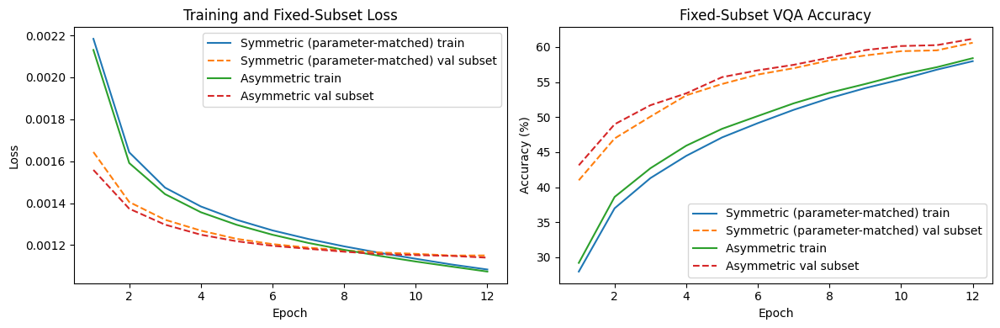

In [26]:
histories = {"Symmetric (parameter-matched)": symmetric_matched_history,
             "Asymmetric": asymmetric_history}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, hist in histories.items():
    epochs = [h["epoch"] for h in hist]
    axes[0].plot(epochs, [h["train_loss"] for h in hist], label=f"{name} train")
    axes[0].plot(epochs, [h["val_loss"] for h in hist], "--", label=f"{name} val subset")
    axes[1].plot(epochs, [h["train_acc"] for h in hist], label=f"{name} train")
    axes[1].plot(epochs, [h["val_vqa_acc"] for h in hist], "--", label=f"{name} val subset")

axes[0].set(xlabel="Epoch", ylabel="Loss", title="Training and Fixed-Subset Loss")
axes[1].set(xlabel="Epoch", ylabel="Accuracy (%)", title="Fixed-Subset VQA Accuracy")
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Comparison Bar Chart

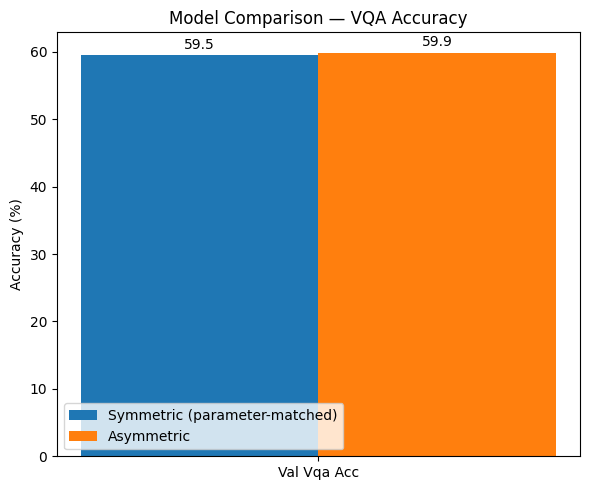

In [27]:
metric_names = ["val_vqa_acc"]
model_names = list(results.keys())
x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 5))
for i, name in enumerate(model_names):
    values = [results[name][m] for m in metric_names]
    bars = ax.bar(x + i * width, values, width, label=name)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x + width / 2)
ax.set_xticklabels([m.replace("_", " ").title() for m in metric_names])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Comparison — VQA Accuracy")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# !mkdir -p /content/drive/MyDrive/frozen_results_ViT_CLIP_RoBERTa/

# !cp -r /content/results/ /content/drive/MyDrive/frozen_results_ViT_CLIP_RoBERTa/

### Visualization Preparation

Reattach the frozen backbones to the trained projection/fusion models and reload the
raw validation data for visualization.

In [29]:
# The raw dataset (images + question strings) is needed for visualization.
if FREEZE_ENCODERS:
    raw_val_ds = VQADataset(
        questions_file=DATA_DIR / "questions" / "v2_OpenEnded_mscoco_val2014_questions.json",
        annotations_file=DATA_DIR / "answers" / "v2_mscoco_val2014_annotations.json",
        h5_path=h5_path,
        answer_to_idx=answer_to_idx,
        max_question_len=MAX_QUESTION_LEN,
        transform=get_image_transform("val"),
        max_samples=MAX_SAMPLES,
    )
else:
    # val_ds already IS the raw dataset here. Reusing it avoids a second ~2.5 GB
    # copy of the target vectors and guarantees that raw_val_ds.samples[i] lines
    # up with the val_subset_indices used by the per-category analysis below.
    raw_val_ds = val_ds

raw_val_loader = DataLoader(
    raw_val_ds, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)

if FREEZE_ENCODERS:
    class EndToEndVQAWrapper(nn.Module):
        """Wraps a trained fusion model with fresh frozen encoders for visualization."""

        def __init__(self, trained_fusion_model, embed_dim=EMBED_DIM):
            super().__init__()
            self.image_encoder = ImageEncoder(embed_dim, freeze=True)
            self.text_encoder = TextEncoder(embed_dim, freeze=True)
            self.trained_model = trained_fusion_model

        def forward(self, images, input_ids, attention_mask, return_attention=False):
            # Match the cache exactly: frozen raw hidden states, followed by the
            # trained projection layers owned by trained_model.
            img_feats = self.image_encoder.clip(pixel_values=images).last_hidden_state
            txt_feats = self.text_encoder.roberta(
                input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
            return self.trained_model(img_feats, txt_feats, attention_mask, return_attention=return_attention)

    set_seed(SEED)
    e2e_asymmetric = EndToEndVQAWrapper(asymmetric_model).to(device)
    e2e_symmetric_matched = EndToEndVQAWrapper(symmetric_matched_model).to(device)
    e2e_models_dict = {
        "Asymmetric": e2e_asymmetric,
        "Symmetric (parameter-matched)": e2e_symmetric_matched,
    }
else:
    # Models are already end-to-end — use them directly
    e2e_models_dict = {
        "Asymmetric": asymmetric_model,
        "Symmetric (parameter-matched)": symmetric_matched_model,
    }

print(f"raw_val_ds: {len(raw_val_ds):,} samples")
print("End-to-end models ready for visualization.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_n

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_n

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


raw_val_ds: 214,354 samples
End-to-end models ready for visualization.


### 5.3 Attention Heatmaps

Visualize what the asymmetric model attends to: which image regions light up for each question word, and which words are most important for each image patch.

In [30]:
# Visualization helpers
MEAN = np.array(CLIP_MEAN)
STD  = np.array(CLIP_STD)


def denormalize(img_tensor):
    """Convert normalised (3,H,W) tensor to (H,W,3) uint8 array."""
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * STD + MEAN
    return np.clip(img * 255, 0, 255).astype(np.uint8)


def decode_tokens(input_ids):
    """Decode token IDs to readable strings."""
    tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
    return [tokenizer.decode(tid) for tid in input_ids.tolist()]


@torch.no_grad()
def get_attention_weights(model, image, input_ids, attention_mask):
    """Run a single sample and return attention weight dicts."""
    model.eval()
    img = image.unsqueeze(0).to(device)
    ids = input_ids.unsqueeze(0).to(device)
    mask = attention_mask.unsqueeze(0).to(device)
    _, attn = model(img, ids, mask, return_attention=True)
    return {k: v.cpu() for k, v in attn.items()}


def plot_image_attention(attn_t2i, image_tensor, tokens, question, top_tokens=4):
    """Overlay text->image attention heatmaps on the original image."""
    img_np = denormalize(image_tensor)
    attn = attn_t2i.squeeze(0).numpy()  # (N_txt, N_img)

    grid_size = int(np.sqrt(attn.shape[1] - 1))  # 7 for active CLIP ViT-B/32@224
    attn_spatial = attn[:, 1:]  # drop CLS column
    image_wh = (img_np.shape[1], img_np.shape[0])

    # Count how many actual words exist (ignoring padding)
    real_token_count = len([t for t in tokens if t not in ['<pad>']])

    # Only average the attention maps of the real tokens
    combined = attn_spatial[:real_token_count].mean(axis=0).reshape(grid_size, grid_size)

    combined_resized = np.array(
        Image.fromarray(combined).resize(image_wh, Image.BILINEAR))

    token_importance = attn_spatial.sum(axis=1)
    top_idx = token_importance.argsort()[-top_tokens:][::-1]

    n_cols = min(top_tokens, len(top_idx)) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    if n_cols == 1:
        axes = [axes]

    axes[0].imshow(img_np)
    axes[0].imshow(combined_resized, alpha=0.5, cmap="jet")
    axes[0].set_title("Combined")
    axes[0].axis("off")

    for i, idx in enumerate(top_idx):
        if i + 1 >= len(axes):
            break
        token_attn = attn_spatial[idx].reshape(grid_size, grid_size)
        token_resized = np.array(
            Image.fromarray(token_attn).resize(image_wh, Image.BILINEAR))
        label = tokens[idx] if tokens else f"token {idx}"
        axes[i + 1].imshow(img_np)
        axes[i + 1].imshow(token_resized, alpha=0.5, cmap="jet")
        axes[i + 1].set_title(f'"{label}"')
        axes[i + 1].axis("off")

    fig.suptitle(question, fontsize=12)
    fig.tight_layout()
    return fig


def plot_text_attention(attn_img_to_txt, tokens, question):
    """Bar chart of image->text attention per token."""
    attn = attn_img_to_txt.squeeze(0).numpy()
    token_weights = attn.mean(axis=0)

    fig, ax = plt.subplots(figsize=(6, max(3, len(tokens) * 0.35)))
    y_pos = np.arange(len(tokens))
    ax.barh(y_pos, token_weights, color="steelblue")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Mean attention weight")
    ax.set_title(f"Image -> Text attention\n{question}")
    fig.tight_layout()
    return fig


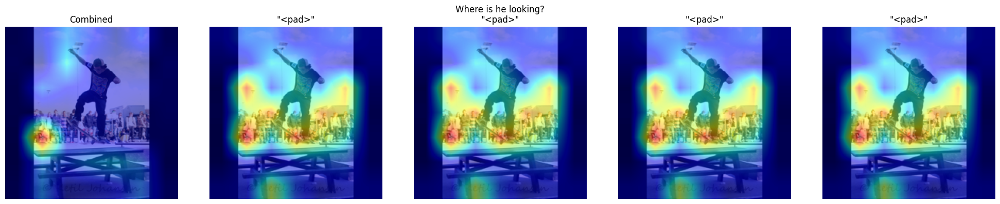

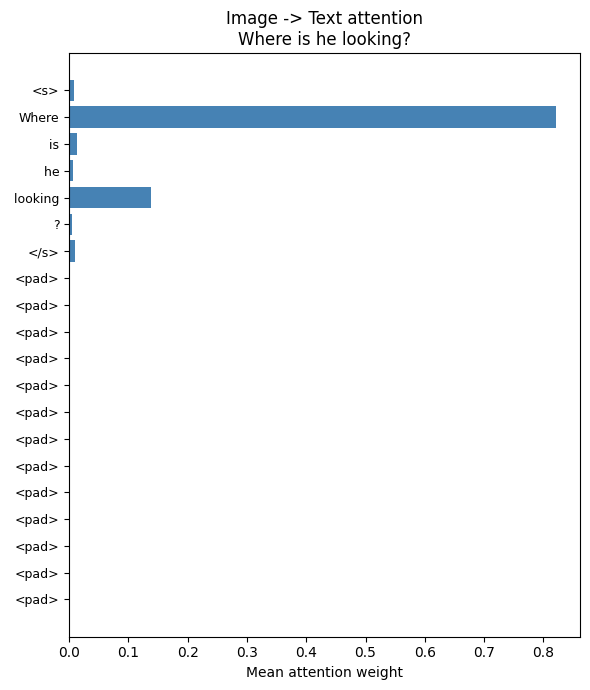

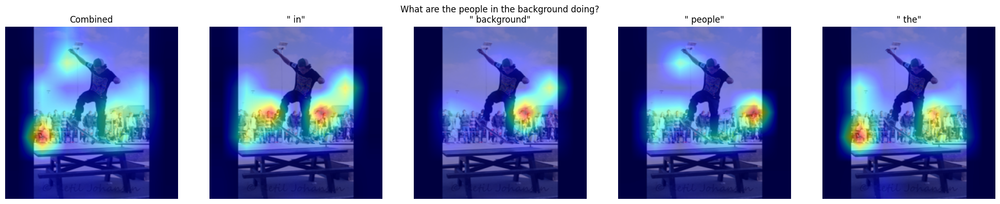

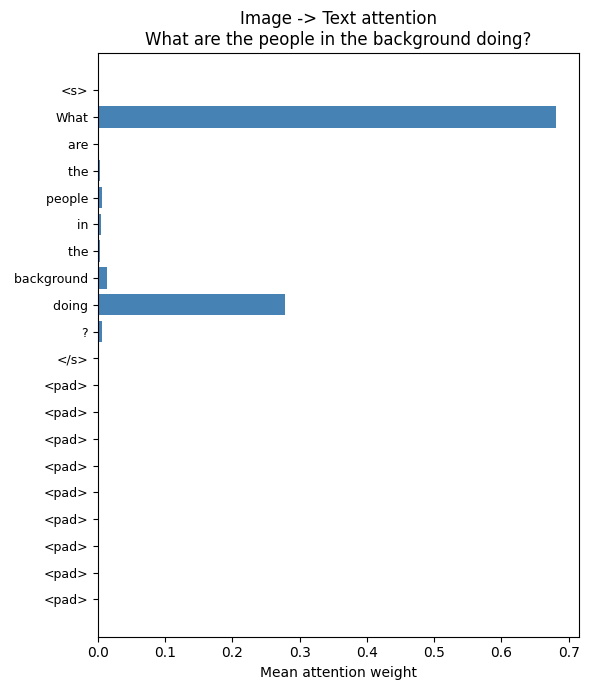

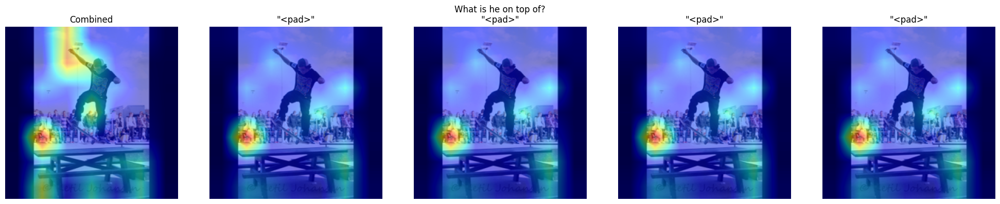

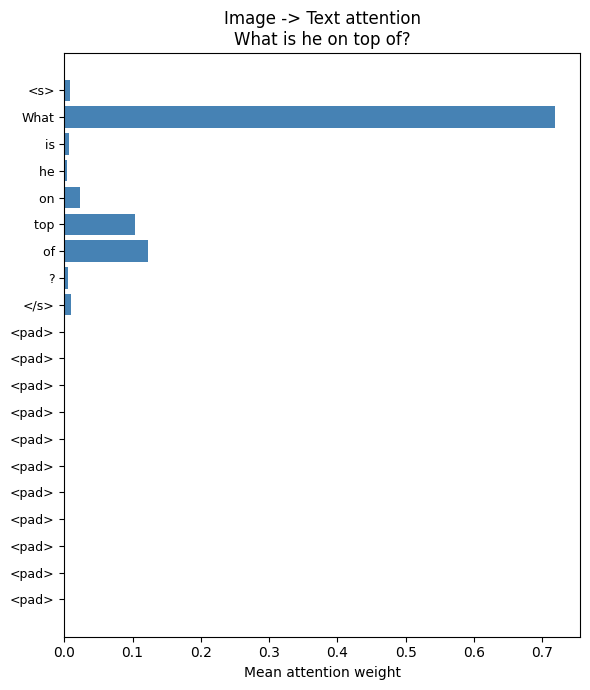

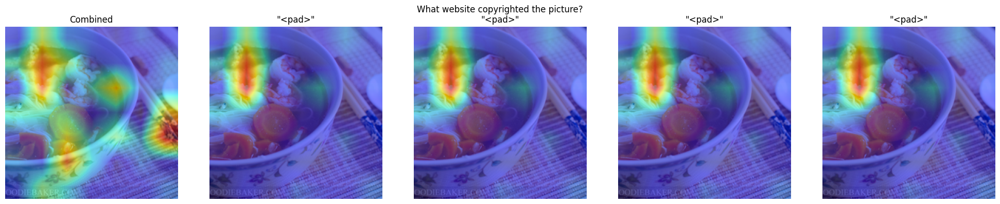

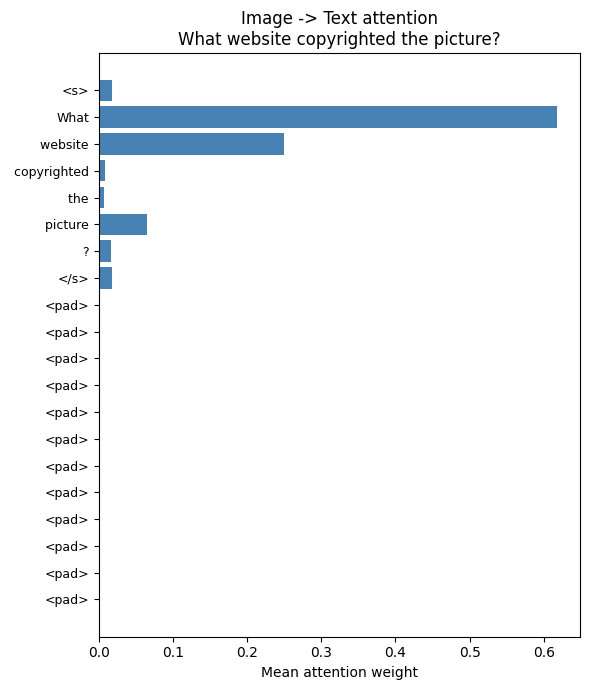

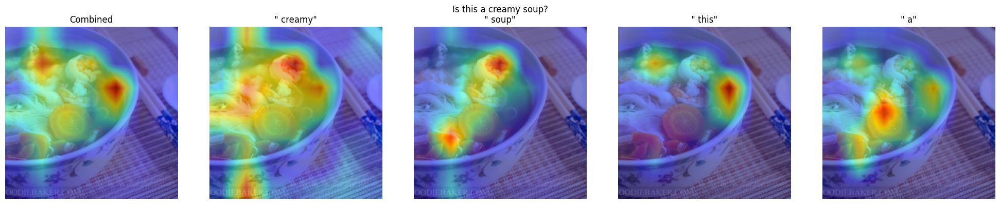

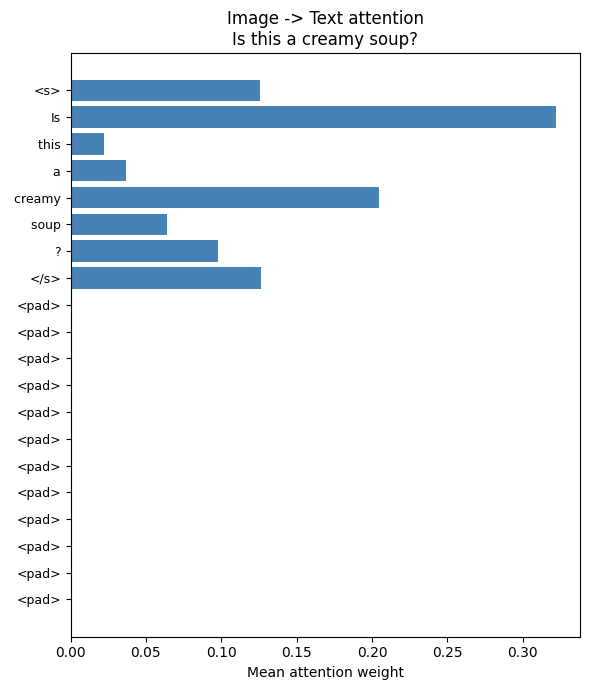

In [31]:
# Generate attention maps for sample validation images
for i in range(min(5, len(raw_val_ds))):
    image, input_ids, attention_mask, answer_target = raw_val_ds[i]
    question = raw_val_ds.samples[i]["question"]
    tokens = decode_tokens(input_ids)

    attn = get_attention_weights(e2e_models_dict["Asymmetric"], image, input_ids, attention_mask)

    fig = plot_image_attention(attn["txt_to_img"], image, tokens, question)
    fig.savefig(FIGURES_DIR / f"attn_img_{i}.png", dpi=150, bbox_inches="tight")
    plt.show()

    fig = plot_text_attention(attn["img_to_txt"], tokens, question)
    fig.savefig(FIGURES_DIR / f"attn_txt_{i}.png", dpi=150, bbox_inches="tight")
    plt.show()

### 5.4 Qualitative Comparison Grid

Side-by-side predictions and attention maps for both models on the same samples.

In [32]:
@torch.no_grad()
def qualitative_grid(models, dataset, idx_to_answer, n_samples=6, save_path=None):
    """Grid of qualitative examples comparing models."""
    sample_indices = torch.randperm(len(dataset))[:n_samples].tolist()
    model_names = list(models.keys())
    n_cols = 1 + len(model_names)
    n_rows = len(sample_indices)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(sample_indices):
        image, input_ids, attention_mask, answer_target = dataset[idx]
        question = dataset.samples[idx]["question"]
        gt_answer = dataset.samples[idx]["multiple_choice_answer"]
        img_np = denormalize(image)
        image_wh = (img_np.shape[1], img_np.shape[0])

        # Column 0: original image + question
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(f"Q: {question}\nGT: {gt_answer}", fontsize=9)
        axes[row, 0].axis("off")

        # Remaining columns: one per model
        for col, name in enumerate(model_names, start=1):
            model = models[name]
            attn = get_attention_weights(model, image, input_ids, attention_mask)

            img_t = image.unsqueeze(0).to(device)
            ids_t = input_ids.unsqueeze(0).to(device)
            mask_t = attention_mask.unsqueeze(0).to(device)
            logits, _ = model(img_t, ids_t, mask_t)
            pred_answer = idx_to_answer.get(logits.argmax(dim=1).item(), "???")

            # Attention heatmap
            attn_t2i = attn["txt_to_img"].squeeze(0).numpy()
            grid_size = int(np.sqrt(attn_t2i.shape[1] - 1))
            combined = attn_t2i[:, 1:].mean(axis=0).reshape(grid_size, grid_size)
            combined_resized = np.array(
                Image.fromarray(combined).resize(image_wh, Image.BILINEAR))

            axes[row, col].imshow(img_np)
            axes[row, col].imshow(combined_resized, alpha=0.5, cmap="jet")
            marker = f"VQA score {answer_target[logits.argmax(1).item()].item():.1f}"
            axes[row, col].set_title(f"{name}\nPred: {pred_answer} ({marker})", fontsize=9)
            axes[row, col].axis("off")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


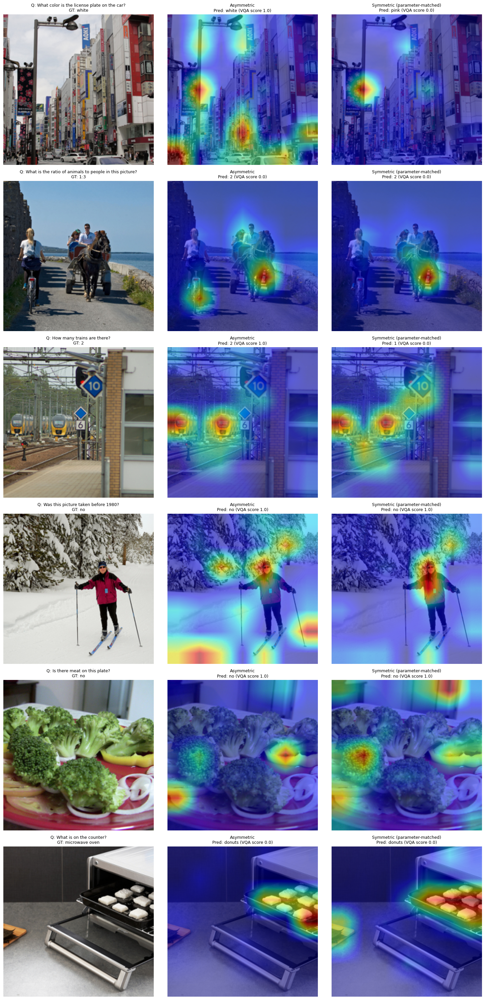

In [33]:
fig = qualitative_grid(
    e2e_models_dict, raw_val_ds, idx_to_answer, n_samples=6,
    save_path=str(FIGURES_DIR / "qualitative_grid.png"))
plt.show()

Running Error Analysis... skipping 10 cases


--- Found a divergent case ---
Target Answer: no
Asymmetric Guess: no (Correct)
Symmetric Guess: yes (Wrong)


Question: Is  there  a  rope  or  chain  between  the  poles ??

=== ASYMMETRIC MODEL ATTENTION (Correct Guess) ===


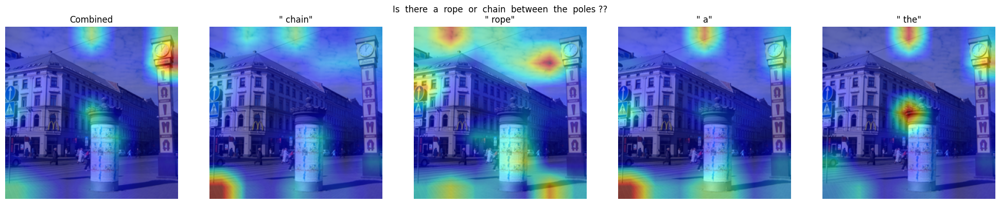

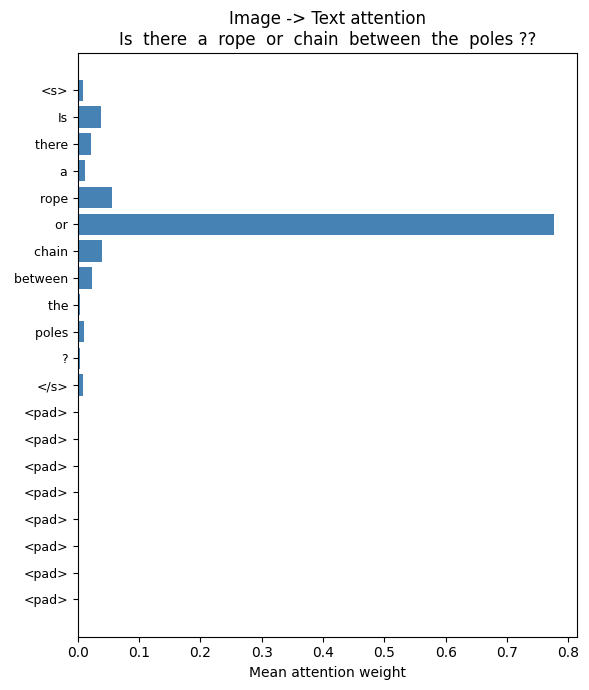


=== SYMMETRIC MODEL ATTENTION (Wrong Guess) ===


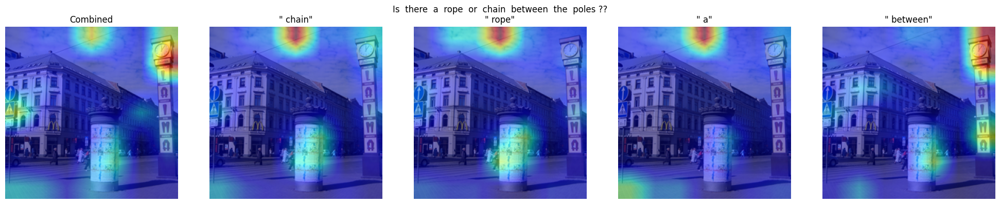

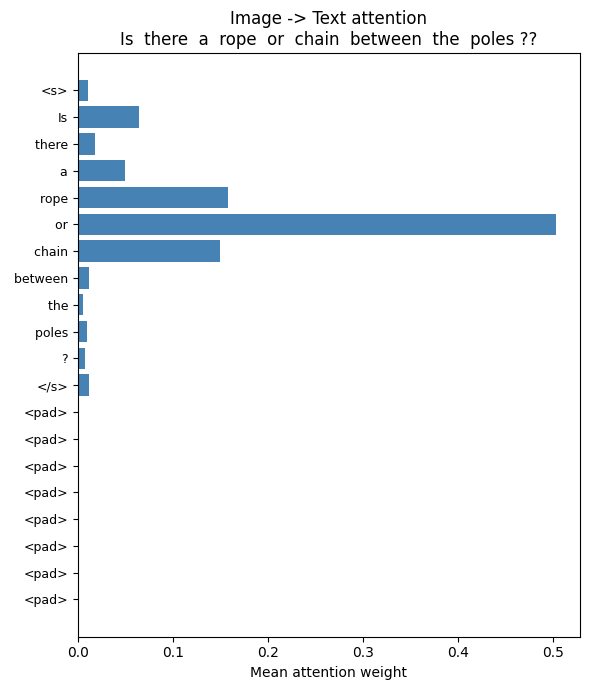

In [34]:
@torch.no_grad()
def error_analysis(models, loader, idx_to_answer, skip_n=1):
    print(f"Running Error Analysis... skipping {skip_n} cases")
    asym_model = models["Asymmetric"]
    sym_model = models["Symmetric (parameter-matched)"]

    asym_model.eval()
    sym_model.eval()

    cases_found = 0

    for images, input_ids, attention_mask, answers in loader:
        images = images.to(device, non_blocking=True)
        input_ids = input_ids.to(device, non_blocking=True)
        attention_mask = attention_mask.to(device, non_blocking=True)
        answers = answers.to(device, non_blocking=True)
        targets = answers.argmax(dim=1)

        asym_logits, _ = asym_model(images, input_ids, attention_mask)
        sym_logits, _ = sym_model(images, input_ids, attention_mask)

        asym_preds = asym_logits.argmax(dim=1)
        sym_preds = sym_logits.argmax(dim=1)

        # Explicitly selected diagnostic examples; aggregate metrics use every question.
        asym_scores = answers.gather(1, asym_preds[:, None]).squeeze(1)
        sym_scores = answers.gather(1, sym_preds[:, None]).squeeze(1)
        mask = (asym_scores == 1) & (sym_scores == 0)
        divergent_indices = mask.nonzero(as_tuple=True)[0]

        for idx in divergent_indices:
            if cases_found < skip_n:
                cases_found += 1
                continue

            print("--- Found a divergent case ---")
            print(f"Target Answer: {idx_to_answer[targets[idx].item()]}")
            print(f"Asymmetric Guess: {idx_to_answer[asym_preds[idx].item()]} (Correct)")
            print(f"Symmetric Guess: {idx_to_answer[sym_preds[idx].item()]} (Wrong)")

            # Extract the specific sample for visualization
            img = images[idx].cpu()
            ids = input_ids[idx].cpu()
            mask_ = attention_mask[idx].cpu()

            # Decode tokens to reconstruct a readable question
            tokens = decode_tokens(ids)
            clean_tokens = [t.replace('\u0120', '') for t in tokens if t not in ['<pad>', '<s>', '</s>']]
            question_str = " ".join(clean_tokens).strip() + "?"
            print(f"Question: {question_str}")

            # Get attention weights for BOTH models
            attn_asym = get_attention_weights(asym_model, img, ids, mask_)
            attn_sym = get_attention_weights(sym_model, img, ids, mask_)

            print("\n=== ASYMMETRIC MODEL ATTENTION (Correct Guess) ===")
            fig_img_asym = plot_image_attention(attn_asym["txt_to_img"], img, tokens, question_str)
            plt.show()
            fig_txt_asym = plot_text_attention(attn_asym["img_to_txt"], tokens, question_str)
            plt.show()

            print("\n=== SYMMETRIC MODEL ATTENTION (Wrong Guess) ===")
            fig_img_sym = plot_image_attention(attn_sym["txt_to_img"], img, tokens, question_str)
            plt.show()
            fig_txt_sym = plot_text_attention(attn_sym["img_to_txt"], tokens, question_str)
            plt.show()

            return

analysis_loader = DataLoader(
    torch.utils.data.Subset(raw_val_ds, val_subset_indices),
    batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)
error_analysis(e2e_models_dict, analysis_loader, idx_to_answer, skip_n=10)

# Task
Categorize the validation questions by type (e.g., 'Is/Are', 'How many', 'What color') and compute the accuracy for both the symmetric and asymmetric models per category, generating a grouped bar chart to visualize the results. Additionally, conduct a comprehensive modality ablation test by evaluating both models under three conditions: Full Data, Image-Blind (zeroed images), and Text-Blind (zeroed input IDs/masks), and generate a grouped bar chart showing the degradation. Finally, provide a brief summary of the insights gained from these new evaluation metrics to help frame the presentation.

## Question Type Accuracy Breakdown

### Subtask:
Categorize validation questions by type, calculate accuracy per category for both models, and plot a grouped bar chart.


Evaluating by question type:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_40649/387280907.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_ctx = autocast() if use_amp else nullcontext()


Evaluating by question type:  20%|██        | 1/5 [00:11<00:45, 11.42s/it]

Evaluating by question type:  40%|████      | 2/5 [00:11<00:14,  4.85s/it]

Evaluating by question type:  60%|██████    | 3/5 [00:11<00:05,  2.74s/it]

Evaluating by question type:  80%|████████  | 4/5 [00:12<00:01,  1.75s/it]

Evaluating by question type: 100%|██████████| 5/5 [00:12<00:00,  1.20s/it]

Evaluating by question type: 100%|██████████| 5/5 [00:12<00:00,  2.57s/it]

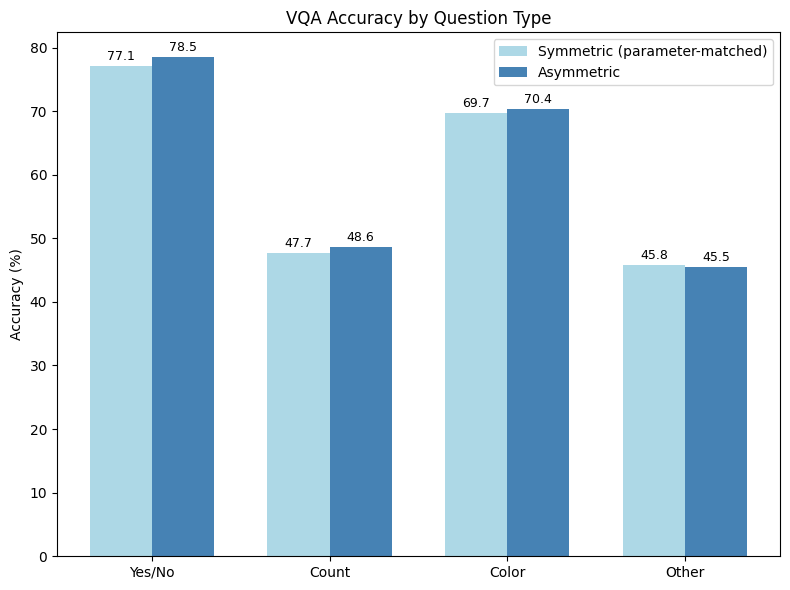

In [35]:
from collections import defaultdict

# 1. Categorize question function
def categorize_question(question):
    q_lower = question.lower().strip()
    if q_lower.startswith(('is ', 'are ', 'was ', 'were ', 'does ', 'do ', 'has ', 'have ', 'can ', 'could ', 'would ', 'should ')):
        return 'Yes/No'
    elif q_lower.startswith('how many'):
        return 'Count'
    elif q_lower.startswith('what color'):
        return 'Color'
    else:
        return 'Other'

@torch.no_grad()
def evaluate_by_question_type(models, loader, question_samples):
    """Evaluate VQA accuracy broken down by question type.
    Uses the fixed validation subset for inference and aligned question text."""
    for model in models.values():
        model.eval()

    category_scores = {name: defaultdict(list) for name in models.keys()}
    global_idx = 0

    use_amp = USE_AMP and device.type == "cuda"

    for inp1, inp2, masks, answers in tqdm(loader, desc="Evaluating by question type"):
        inp1    = inp1.to(device, non_blocking=True)
        inp2    = inp2.to(device, non_blocking=True)
        masks   = masks.to(device, non_blocking=True)
        answers = answers.to(device, non_blocking=True)

        batch_size = inp1.size(0)

        preds_dict = {}
        for name, model in models.items():
            amp_ctx = autocast() if use_amp else nullcontext()
            with amp_ctx:
                logits, _ = model(inp1, inp2, masks)
            preds_dict[name] = logits.argmax(dim=1)

        # 3. Calculate category score per sample. Targets already store VQA scores.
        for i in range(batch_size):
            question = question_samples[global_idx + i]["question"]
            category = categorize_question(question)

            for name, preds in preds_dict.items():
                pred_idx = preds[i]
                vqa_score = answers[i, pred_idx].item()
                category_scores[name][category].append(vqa_score)

        global_idx += batch_size

    # 4. Aggregate scores
    category_acc = {name: {} for name in models.keys()}
    for name, cat_scores in category_scores.items():
        for cat, scores in cat_scores.items():
            category_acc[name][cat] = np.mean(scores) * 100

    return category_acc

# Reuse the fixed 10K subset; full validation was already completed above.
analysis_question_samples = [raw_val_ds.samples[i] for i in val_subset_indices]
category_acc = evaluate_by_question_type(
    {"Symmetric (parameter-matched)": symmetric_matched_model,
     "Asymmetric": asymmetric_model},
    val_subset_loader, analysis_question_samples)

# 5. Generate a grouped bar chart
categories = ['Yes/No', 'Count', 'Color', 'Other']
sym_acc = [category_acc["Symmetric (parameter-matched)"].get(cat, 0)
           for cat in categories]
asym_acc = [category_acc["Asymmetric"].get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, sym_acc, width,
               label='Symmetric (parameter-matched)', color='lightblue')
bars2 = ax.bar(x + width/2, asym_acc, width, label='Asymmetric', color='steelblue')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel('Accuracy (%)')
ax.set_title('VQA Accuracy by Question Type')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "question_type_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


## Modality Ablation Test

Evaluate both models under three conditions: Full Data, Image-Blind (zeroed images), and Text-Blind (zeroed input IDs/masks), and generate a grouped bar chart showing the degradation.


Running ablation for Symmetric (parameter-matched)...


Eval Full Data:   0%|          | 0/5 [00:00<?, ?it/s]

Eval Full Data:  20%|██        | 1/5 [00:03<00:14,  3.65s/it]

Eval Full Data:  40%|████      | 2/5 [00:03<00:04,  1.57s/it]

Eval Full Data:  80%|████████  | 4/5 [00:03<00:00,  1.62it/s]

...

Eval Text-Blind:  20%|██        | 1/5 [00:03<00:15,  3.78s/it]

Eval Text-Blind:  60%|██████    | 3/5 [00:03<00:02,  1.04s/it]

Eval Text-Blind: 100%|██████████| 5/5 [00:04<00:00,  1.88it/s]

Eval Text-Blind: 100%|██████████| 5/5 [00:04<00:00,  1.11it/s]

  Text-Blind: 19.83%


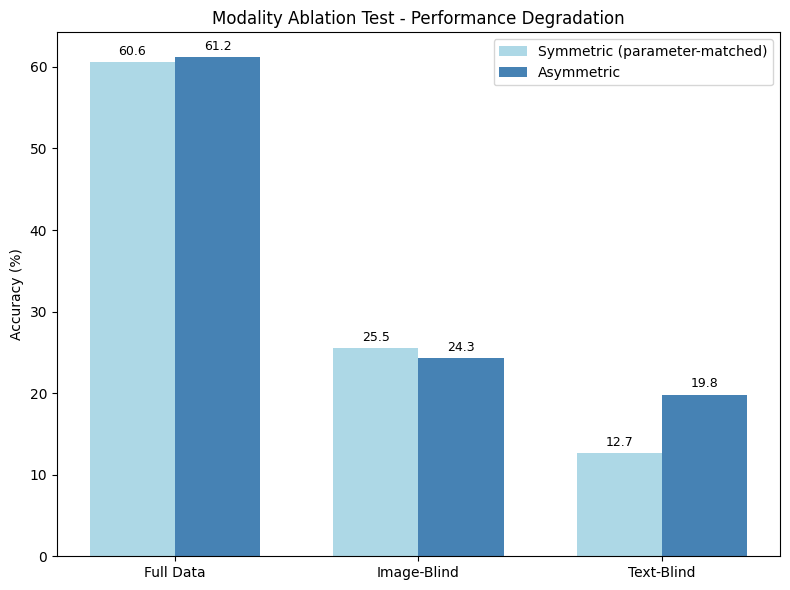

In [36]:
@torch.no_grad()
def evaluate_ablation(model, loader, condition):
    """Evaluate model under ablation conditions."""
    model.eval()
    vqa_acc_sum = 0.0
    total = 0
    use_amp = USE_AMP and device.type == "cuda"

    for inp1, inp2, masks, answers in tqdm(loader, desc=f"Eval {condition}"):
        if condition == "Image-Blind":
            inp1 = torch.zeros_like(inp1)
        elif condition == "Text-Blind":
            if FREEZE_ENCODERS:
                inp2 = torch.zeros_like(inp2)     # zero out precomputed text features
            else:
                inp2 = torch.ones_like(inp2)      # RoBERTa padding token ID = 1
            # The mask must stay all-ones. Zeroing it makes every key padded, and
            # nn.MultiheadAttention then softmaxes a row of -inf into NaN, which
            # silently turns this bar into "whatever answer index 0 scores".
            # Constant pad tokens already carry no question information.
            masks = torch.ones_like(masks)

        inp1    = inp1.to(device, non_blocking=True)
        inp2    = inp2.to(device, non_blocking=True)
        masks   = masks.to(device, non_blocking=True)
        answers = answers.to(device, non_blocking=True)

        amp_ctx = torch.amp.autocast('cuda') if use_amp else nullcontext()
        with amp_ctx:
            logits, _ = model(inp1, inp2, masks)

        preds = logits.argmax(dim=1)
        vqa_scores = answers[torch.arange(answers.size(0), device=answers.device), preds]
        vqa_acc_sum += vqa_scores.sum().item()
        total += answers.size(0)

    return vqa_acc_sum / total * 100

# Reuse the fixed validation subset for the six ablation passes.
models_dict = {"Symmetric (parameter-matched)": symmetric_matched_model,
               "Asymmetric": asymmetric_model}

conditions = ["Full Data", "Image-Blind", "Text-Blind"]
ablation_results = {name: {} for name in models_dict}

for model_name, model in models_dict.items():
    print(f"\nRunning ablation for {model_name}...")
    for cond in conditions:
        acc = evaluate_ablation(model, val_subset_loader, cond)
        ablation_results[model_name][cond] = acc
        print(f"  {cond}: {acc:.2f}%")

# Plotting the results
x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
sym_accs = [ablation_results["Symmetric (parameter-matched)"][cond]
            for cond in conditions]
asym_accs = [ablation_results["Asymmetric"][cond] for cond in conditions]

bars1 = ax.bar(x - width/2, sym_accs, width,
               label='Symmetric (parameter-matched)', color='lightblue')
bars2 = ax.bar(x + width/2, asym_accs, width, label='Asymmetric', color='steelblue')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Modality Ablation Test - Performance Degradation')
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "ablation_test.png", dpi=150, bbox_inches="tight")
plt.show()


# Task
Create a helper function `visualize_category_example` that searches the validation dataset for a question of a specified category and plots the attention heatmaps for both models. Use this function to find and visualize examples for the 'Yes/No', 'Count', 'Color', and 'Other' categories, adding appropriate text and code cells for each, and conclude with a brief summary of these visualizations.

## Define Category Visualization Helper

### Subtask:
Create a helper function to search for and visualize a specific question category.


In [37]:
def visualize_category_example(category, dataset, models_dict, idx_to_answer):
    print(f"Searching for an example in category: {category}...")
    for i in range(len(dataset)):
        question = dataset.samples[i]["question"]
        if categorize_question(question) == category:
            image, input_ids, attention_mask, answer_target = dataset[i]
            gt_answer = dataset.samples[i]["multiple_choice_answer"]

            img_t = image.unsqueeze(0).to(device)
            ids_t = input_ids.unsqueeze(0).to(device)
            mask_t = attention_mask.unsqueeze(0).to(device)

            # Decode tokens to reconstruct a readable question
            tokens = decode_tokens(input_ids)
            clean_tokens = [t.replace('Ġ', '') for t in tokens if t not in ['<pad>', '<s>', '</s>']]
            question_str = " ".join(clean_tokens).strip() + "?"

            print("\n" + "="*40)
            print(f"Category: {category}")
            print(f"Question: {question_str}")
            print(f"Target Answer: {gt_answer}")
            print("="*40)

            for model_name, model in models_dict.items():
                model.eval()
                with torch.no_grad():
                    logits, _ = model(img_t, ids_t, mask_t)
                pred_answer = idx_to_answer.get(logits.argmax(dim=1).item(), "???")
                print(f"{model_name} Guess: {pred_answer}")

            for model_name, model in models_dict.items():
                print(f"\n=== {model_name.upper()} MODEL ATTENTION ===")
                attn = get_attention_weights(model, image, input_ids, attention_mask)

                # Plot text -> image attention
                fig_img = plot_image_attention(attn["txt_to_img"], image, tokens, question_str)
                plt.show()

                # Plot image -> text attention
                fig_txt = plot_text_attention(attn["img_to_txt"], tokens, question_str)
                plt.show()

            return

    print(f"No example found for category: {category}")

## Visualize Yes/No Question

### Subtask:
Find and visualize an example for the 'Yes/No' question category.


Searching for an example in category: Yes/No...



Category: Yes/No
Question: Is  this  a  creamy  soup ??
Target Answer: no
Asymmetric Guess: yes
Symmetric (parameter-matched) Guess: no

=== ASYMMETRIC MODEL ATTENTION ===


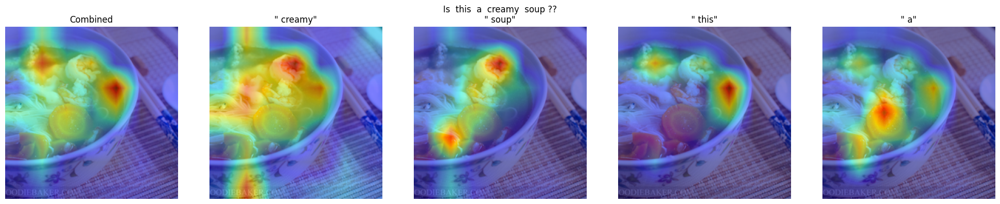

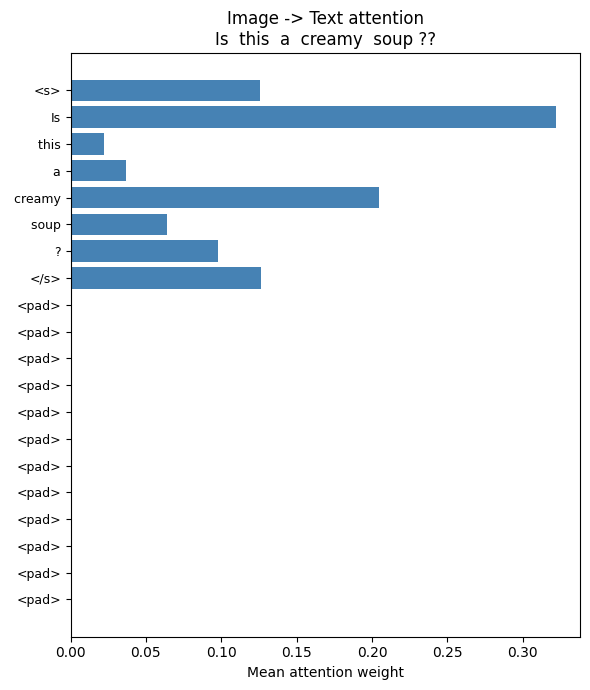


=== SYMMETRIC (PARAMETER-MATCHED) MODEL ATTENTION ===


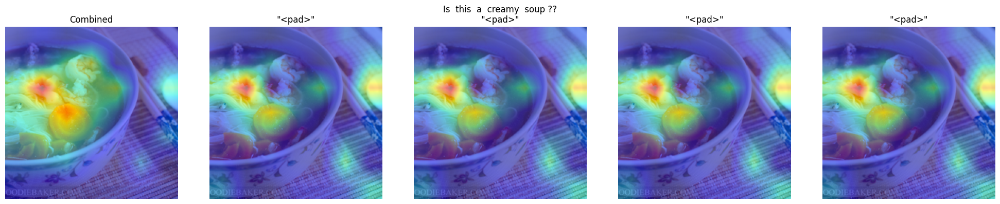

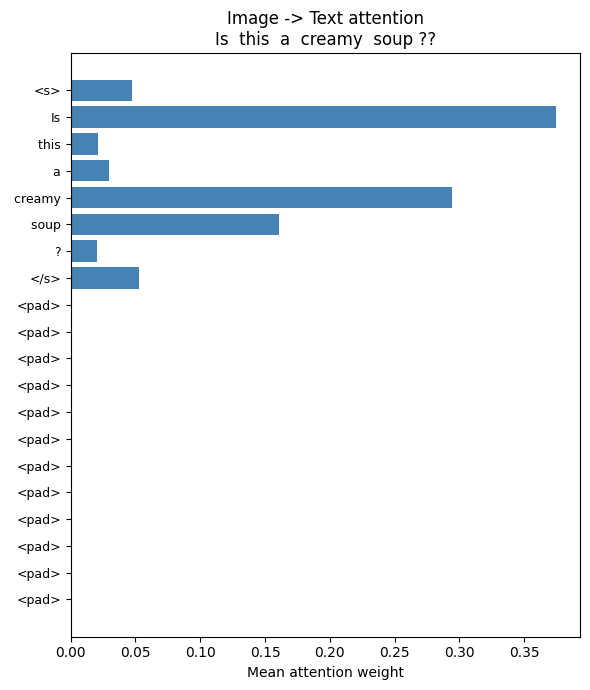

In [38]:
visualize_category_example("Yes/No", raw_val_ds, e2e_models_dict, idx_to_answer)

## Visualize Count Question

### Subtask:
Find and visualize an example for the 'Count' question category.

Searching for an example in category: Count...



Category: Count
Question: How  many  photo 's  can  you  see ??
Target Answer: 1
Asymmetric Guess: 2
Symmetric (parameter-matched) Guess: 1

=== ASYMMETRIC MODEL ATTENTION ===


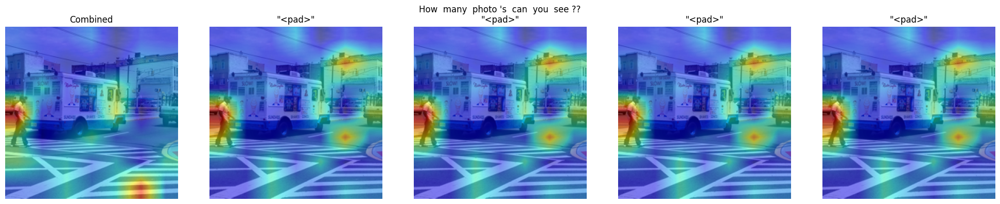

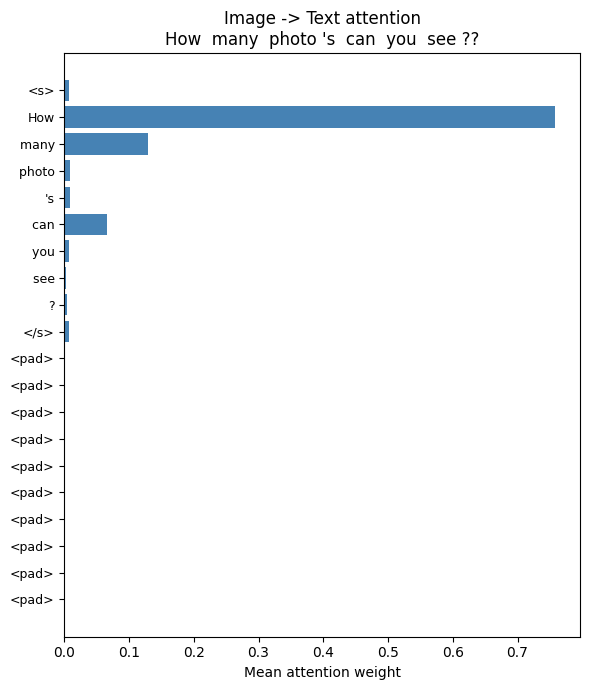


=== SYMMETRIC (PARAMETER-MATCHED) MODEL ATTENTION ===


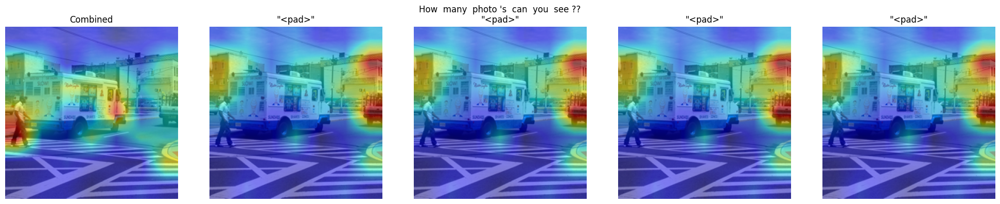

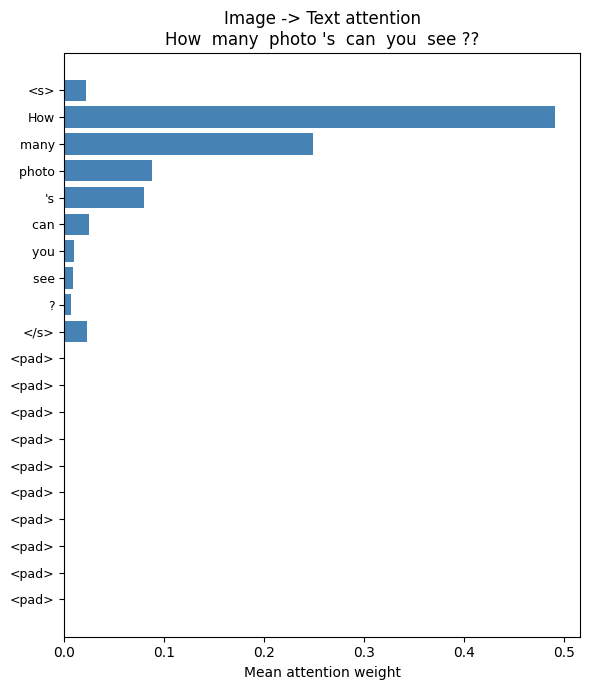

In [39]:
visualize_category_example("Count", raw_val_ds, e2e_models_dict, idx_to_answer)

## Visualize Color Question

### Subtask:
Find and visualize an example for the 'Color' question category.

Searching for an example in category: Color...



Category: Color
Question: What  color  is  the  grass  in  this  picture ??
Target Answer: green
Asymmetric Guess: green
Symmetric (parameter-matched) Guess: green

=== ASYMMETRIC MODEL ATTENTION ===


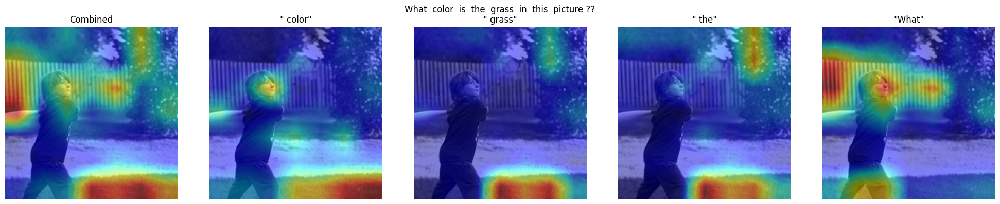

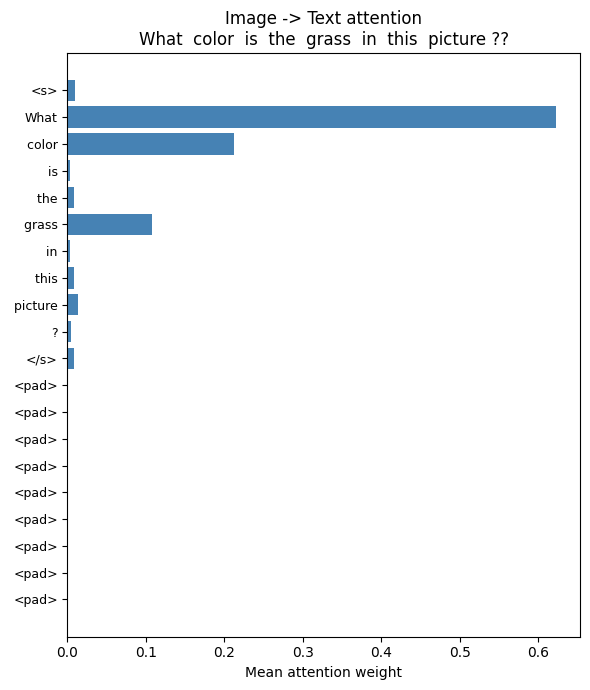


=== SYMMETRIC (PARAMETER-MATCHED) MODEL ATTENTION ===


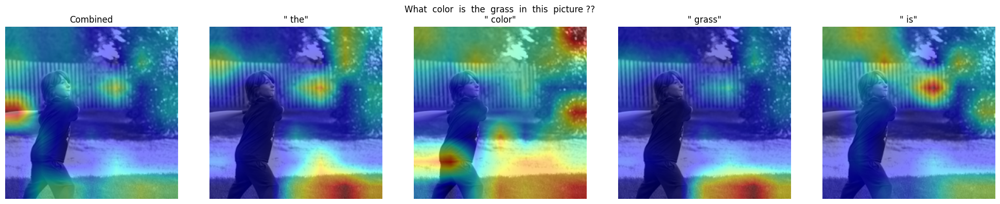

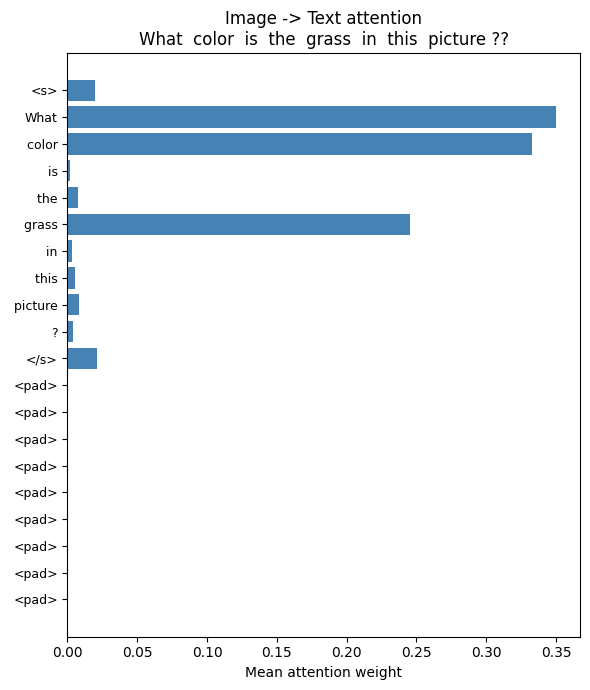

In [40]:
visualize_category_example("Color", raw_val_ds, e2e_models_dict, idx_to_answer)

## Visualize Other Question

### Subtask:
Find and visualize an example for the 'Other' question category.

Searching for an example in category: Other...



Category: Other
Question: Where  is  he  looking ??
Target Answer: down
Asymmetric Guess: down
Symmetric (parameter-matched) Guess: up

=== ASYMMETRIC MODEL ATTENTION ===


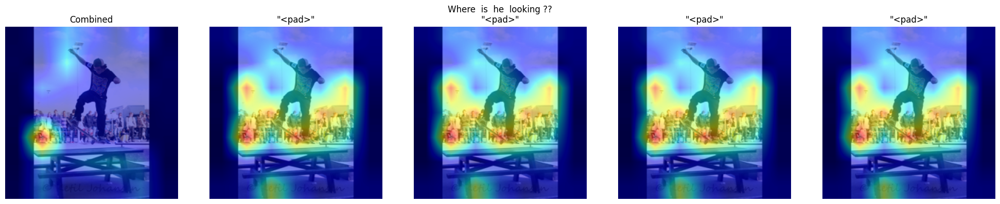

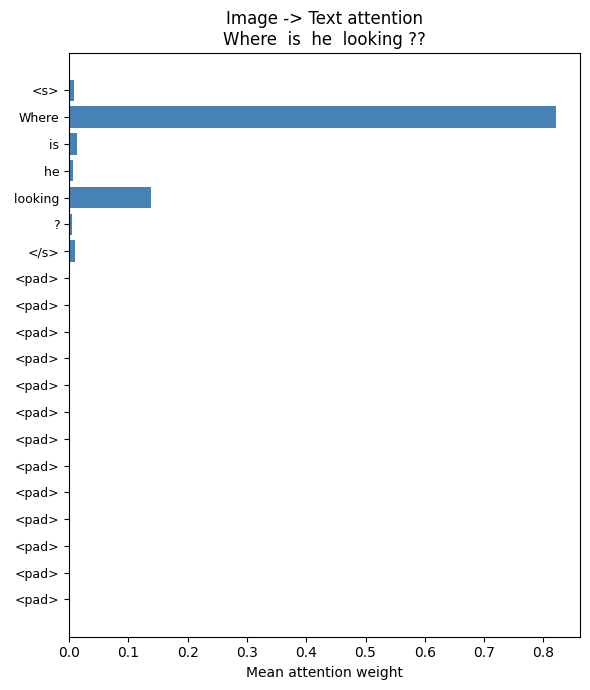


=== SYMMETRIC (PARAMETER-MATCHED) MODEL ATTENTION ===


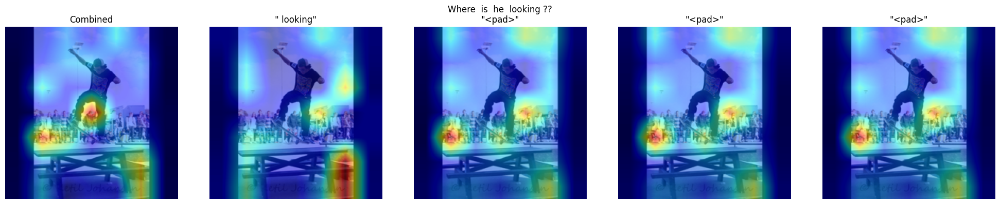

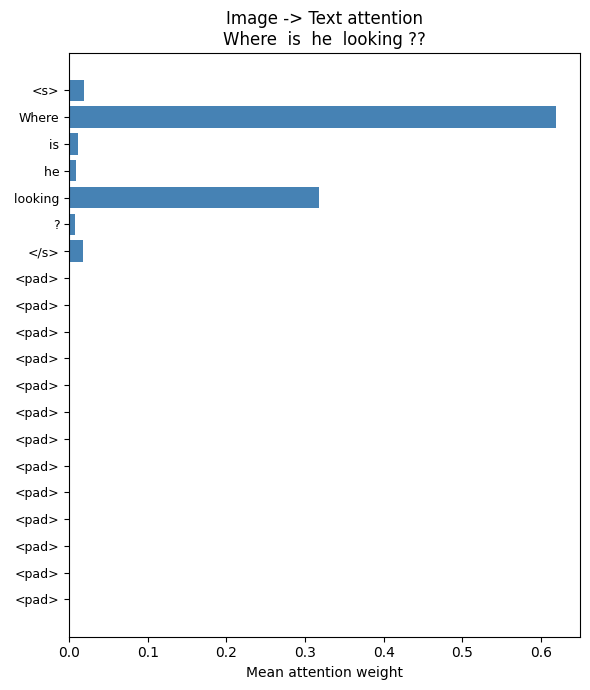

In [41]:
visualize_category_example("Other", raw_val_ds, e2e_models_dict, idx_to_answer)

## Interpreting Category Visualizations

Interpret heatmaps alongside the complete paired-seed results. Both active variants now use parallel updates from original encoder features. Parameter counts match; the symmetric control performs four attention calls and averages shared experts, while the asymmetric model performs two calls with dedicated directional blocks. Heatmaps and selected examples do not establish overall superiority.


In [42]:
# !mkdir -p /content/data/zip/
# !mkdir -p /content/data/images/
# !cp /content/drive/MyDrive/test2015.zip /content/data/zip/

In [43]:
# !unzip -q /content/data/zip/test2015.zip -d /content/data/images/

---
## 6. Test Set Predictions Export

Run inference on the VQA v2.0 **test2015** split (no annotations) and write predictions to JSON in the official VQA submission format: `[{"question_id": int, "answer": str}, ...]`.

Test images aren't in the precomputed feature HDF5, so we load raw JPEGs from `images/test2015/` and run them through the end-to-end models (`e2e_models_dict`, which works for both frozen and unfrozen runs).

In [44]:
class VQATestDataset(Dataset):
    """VQA test split: questions + raw JPEGs from images/test2015/, no annotations."""

    def __init__(self, questions_file, images_dir, max_question_len=20,
                 transform=None, max_samples=None):
        self.images_dir = Path(images_dir) / "test2015"
        self.max_question_len = max_question_len
        self.transform = transform or get_image_transform("val")
        self.tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

        with open(questions_file) as f:
            self.samples = json.load(f)["questions"]
        if max_samples is not None:
            self.samples = self.samples[:max_samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        # test-dev2015 reuses the test2015 image pool, so the filename prefix is
        # always COCO_test2015_* regardless of which question split we loaded.
        img_path = self.images_dir / f"COCO_test2015_{sample['image_id']:012d}.jpg"
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        encoding = self.tokenizer(
            sample["question"],
            max_length=self.max_question_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return (
            image,
            encoding["input_ids"].squeeze(0),
            encoding["attention_mask"].squeeze(0),
            sample["question_id"],
        )


# Use the full test2015 split (~447K questions) — required for any VQA v2
# eval-server submission (test-dev or test-standard). For a quick local
# sanity check during iteration, swap to v2_OpenEnded_mscoco_test-dev2015_questions.json (~107K).
TEST_QUESTIONS_FILE = DATA_DIR / "questions" / "v2_OpenEnded_mscoco_test2015_questions.json"
TEST_IMAGES_DIR = DATA_DIR / "images" / "test2015"
# Test export runs both frozen backbones, unlike cached-head training. Keep
# its batch independent so the 2,048-sample training batch cannot cause OOM.
TEST_BATCH_SIZE = FEATURE_EXTRACTION_BATCH_SIZE if FREEZE_ENCODERS else BATCH_SIZE

# All training and evaluation results are already saved by this point, so a
# missing test split downgrades to a skip rather than failing the whole run.
EXPORT_TEST_PREDICTIONS = TEST_QUESTIONS_FILE.exists() and TEST_IMAGES_DIR.is_dir()

if EXPORT_TEST_PREDICTIONS:
    test_ds = VQATestDataset(
        questions_file=TEST_QUESTIONS_FILE,
        images_dir=DATA_DIR / "images",
        max_question_len=MAX_QUESTION_LEN,
        transform=get_image_transform("val"),
        max_samples=None,  # always export the full test split, regardless of dev MAX_SAMPLES
    )
    test_loader = DataLoader(
        test_ds, batch_size=TEST_BATCH_SIZE, shuffle=False, **_loader_kwargs)
    print(f"Test: {len(test_ds):,} samples ({len(test_loader)} batches)")
else:
    print("Skipping test export — missing "
          f"{TEST_QUESTIONS_FILE if not TEST_QUESTIONS_FILE.exists() else TEST_IMAGES_DIR}")


@torch.no_grad()
def predict_test(model, loader, idx_to_answer):
    """Return [{question_id, answer}, ...] in official VQA submission format."""
    model.eval()
    use_amp = USE_AMP and device.type == "cuda"
    predictions = []

    for images, input_ids, attention_mask, question_ids in tqdm(loader, desc="predict"):
        images = images.to(device, non_blocking=True)
        input_ids = input_ids.to(device, non_blocking=True)
        attention_mask = attention_mask.to(device, non_blocking=True)

        amp_ctx = autocast() if use_amp else nullcontext()
        with amp_ctx:
            logits, _ = model(images, input_ids, attention_mask)
        if not torch.isfinite(logits).all():
            raise FloatingPointError("Non-finite test logits")

        preds = logits.argmax(dim=1).cpu().tolist()
        for qid, p in zip(question_ids.tolist(), preds):
            predictions.append({"question_id": int(qid), "answer": idx_to_answer[int(p)]})

    return predictions


def validate_test_predictions(predictions, questions):
    expected = [int(q["question_id"]) for q in questions]
    ids = []
    for item in predictions:
        if (set(item) != {"question_id", "answer"} or type(item["question_id"]) is not int
                or not isinstance(item["answer"], str) or not item["answer"].strip()):
            raise ValueError("Invalid EvalAI prediction record")
        ids.append(item["question_id"])
    if len(expected) != len(set(expected)) or len(ids) != len(set(ids)) or set(ids) != set(expected):
        raise ValueError("Predictions must cover every test question exactly once")


PREDICTIONS_DIR = OUTPUT_ROOT / "predictions"
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

if EXPORT_TEST_PREDICTIONS:
    if len(test_ds) != 447_793:
        raise ValueError("Full VQA v2 test2015 export expects 447,793 questions; check the question file.")
    for name, model in [("asymmetric", e2e_models_dict["Asymmetric"]),
                        ("symmetric_matched", e2e_models_dict["Symmetric (parameter-matched)"])]:
        selected = selected_runs[name]
        preds = predict_test(model, test_loader, idx_to_answer)
        validate_test_predictions(preds, test_ds.samples)
        out_path = PREDICTIONS_DIR / f"{selected['run_name']}_test_predictions.json"
        temporary = out_path.with_suffix(".json.partial")
        temporary.write_text(json.dumps(preds))
        temporary.replace(out_path)
        metadata = {"model_type": name, "seed": selected["seed"], "epoch": selected["best_epoch"],
                    "checkpoint": selected["checkpoint"], "checkpoint_sha256": file_sha256(selected["checkpoint"]),
                    "vocab_sha256": VOCAB_SHA256, "config_sha256": CONFIG_SHA256,
                    "questions_sha256": file_sha256(TEST_QUESTIONS_FILE),
                    "prediction_count": len(preds), "predictions_sha256": file_sha256(out_path),
                    "selection": "highest fixed-subset accuracy; ties use lower seed then earlier epoch"}
        out_path.with_suffix(".metadata.json").write_text(json.dumps(metadata, indent=2))
        print(f"Validated {len(preds):,} predictions -> {out_path}")
        del preds
else:
    print("Test2015 staging/export deferred. Rerun this section when GCP test data is available.")


Test: 447,793 samples (875 batches)


predict:   0%|          | 0/875 [00:00<?, ?it/s]

/tmp/ipykernel_40649/3171082711.py:83: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_ctx = autocast() if use_amp else nullcontext()


predict:   0%|          | 1/875 [00:10<2:37:03, 10.78s/it]

predict:   0%|          | 2/875 [00:10<1:05:37,  4.51s/it]

...

predict: 100%|█████████▉| 872/875 [11:24<00:01,  2.21it/s]

predict: 100%|█████████▉| 873/875 [11:24<00:00,  2.88it/s]

predict: 100%|█████████▉| 874/875 [11:26<00:00,  1.46it/s]

predict: 100%|██████████| 875/875 [11:27<00:00,  1.27it/s]

Validated 447,793 predictions -> /mnt/vqa-data/work/runs/frozen-gcp-20260913T163839Z/output/predictions/clipB32_224_frozen_top3000_directional_parallel_v1_8d4983bd4bfe_s7_symmetric_matched_test_predictions.json


In [45]:
# !mkdir -p /content/drive/MyDrive/frozen_results_ViT_CLIP_RoBERTa/

# !cp -r /content/results/ /content/drive/MyDrive/frozen_results_ViT_CLIP_RoBERTa/